In [1]:
# Imports and Setup
import os
from dotenv import load_dotenv
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, func, distinct
from sqlalchemy.orm import sessionmaker, aliased
from models import News, NewsSecurities, Securities, HistPrice1D, IvSurf, Options, Stocks
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# Load environment variables and set up database connection
load_dotenv()

DB_SERVER = os.getenv('DB_SERVER')
DB_USER = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_NAME = os.getenv('DB_NAME')

connection_string = f"mssql+pyodbc://{DB_USER}:{DB_PASSWORD}@{DB_SERVER}/{DB_NAME}?driver=ODBC+Driver+17+for+SQL+Server"

engine = create_engine(connection_string)
Session = sessionmaker(bind=engine)
session = Session()

# Set up matplotlib style
plt.style.use('ggplot')

1. Time Series Average Number of Options for Top 20 Stocks:
option_type   average_calls  average_puts       total  call_ratio
stock_ticker                                                     
NVDA             443.401460    380.970803  824.372263    0.537866
SPY              328.569853    407.676471  736.246324    0.446277
MSTR             336.090909    311.454545  647.545455    0.519023
SMCI             340.185606    299.537879  639.723485    0.531770
TSLA             264.485401    212.102190  476.587591    0.554957
AVGO             222.332117    215.821168  438.153285    0.507430
META             233.919708    195.642336  429.562044    0.544554
COIN             218.609848    188.170455  406.780303    0.537415
NFLX             201.664234    181.890511  383.554745    0.525777
AMD              195.270073    158.810219  354.080292    0.551485
ARM              170.322222    159.622222  329.944444    0.516215
BKNG             149.427007    169.372263  318.799270    0.468718
LLY             

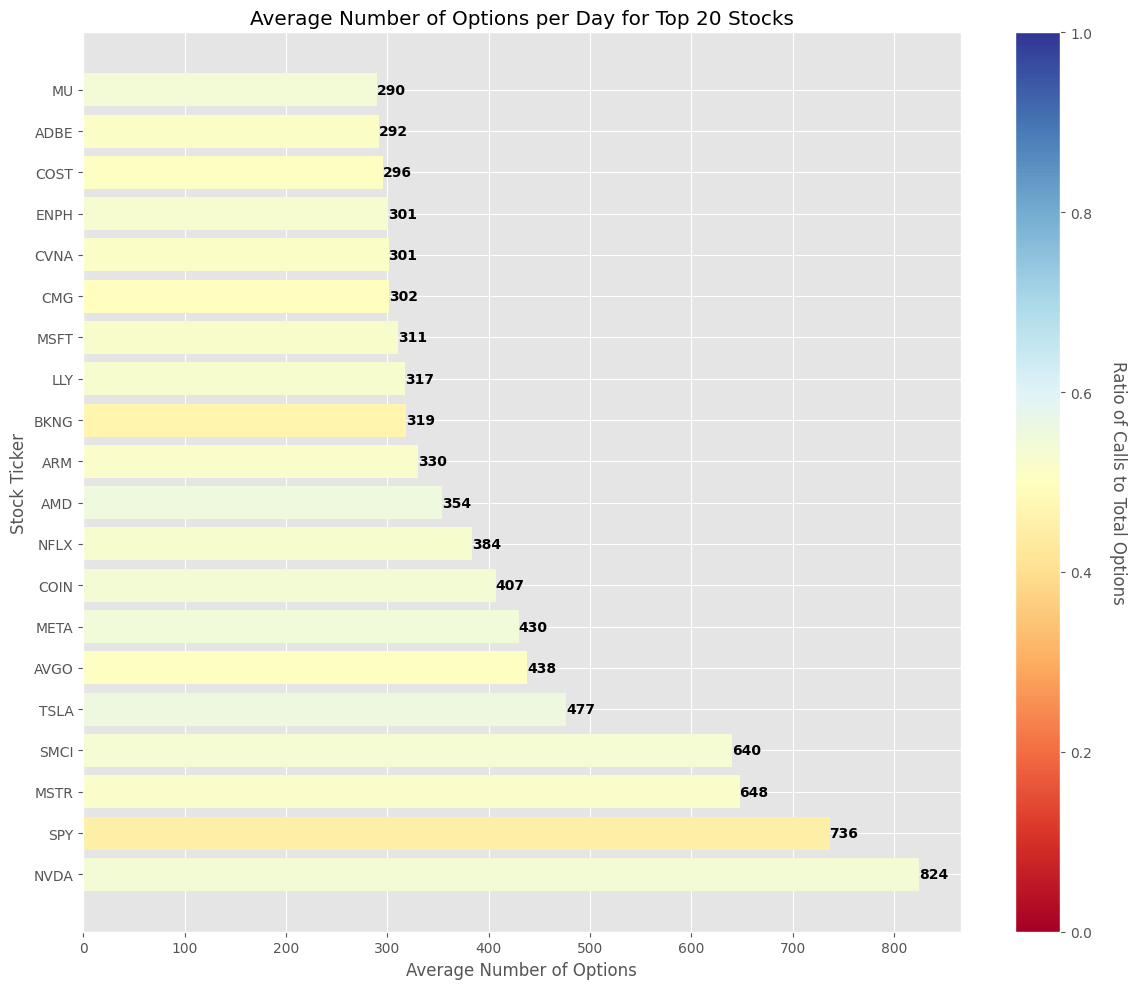

In [2]:
# 1. Options data analysis
SecuritiesOption = aliased(Securities)
SecuritiesStock = aliased(Securities)

options_query = (
    session.query(
        SecuritiesStock.ticker.label('stock_ticker'),
        Options.option_type,
        HistPrice1D.exch_time,
        func.count(Options.ticker).label('option_count')
    )
    .select_from(SecuritiesOption)
    .join(Options, SecuritiesOption.ticker == Options.ticker)
    .join(SecuritiesStock, SecuritiesOption.underlying_ticker == SecuritiesStock.ticker)
    .join(HistPrice1D, (HistPrice1D.ticker == Options.ticker) & (HistPrice1D.exch_time <= Options.expiry))
    .filter(SecuritiesOption.security_type == 'opt')
    .group_by(SecuritiesStock.ticker, Options.option_type, HistPrice1D.exch_time)
)

options_df = pd.read_sql(options_query.statement, session.bind)

# Calculate average number of options per day for each stock and option type
options_avg = options_df.groupby(['stock_ticker', 'option_type'])['option_count'].mean().unstack(fill_value=0)
options_avg = options_avg.rename(columns={'call': 'average_calls', 'put': 'average_puts'})
options_avg['total'] = options_avg['average_calls'] + options_avg['average_puts']
options_avg['call_ratio'] = options_avg['average_calls'] / options_avg['total']

# Sort by total and get top 20 stocks
top_20 = options_avg.sort_values('total', ascending=False).head(20)

print("1. Time Series Average Number of Options for Top 20 Stocks:")
print(top_20)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(top_20.index, top_20['total'], color=plt.cm.RdYlBu(top_20['call_ratio']))
ax.set_title('Average Number of Options per Day for Top 20 Stocks')
ax.set_xlabel('Average Number of Options')
ax.set_ylabel('Stock Ticker')

# Add value labels to the end of each bar
for i, bar in enumerate(bars):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2, 
            f'{top_20["total"].iloc[i]:.0f}', 
            va='center', ha='left', fontweight='bold')

# Create a colorbar legend
sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlBu, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Ratio of Calls to Total Options', rotation=270, labelpad=25)

plt.tight_layout()
plt.show()


2. IV Surface Data Analysis:

Descriptive Statistics of Stocks with Incomplete IV Surface Data:
count    163.000000
mean       0.872450
std        0.254914
min        0.000000
25%        0.943611
50%        0.988417
75%        0.988417
max        0.995851
Name: iv_surf_proportion, dtype: float64

Number of stocks with complete IV surface data: 228
Number of stocks with incomplete IV surface data: 163

Bottom 20 Stocks with Lowest Proportion of IV Surface Data:
    ticker  iv_surf_proportion
21     NOV            0.000000
22    EXAS            0.000000
56    HUBS            0.000000
97     SYY            0.000000
248     DT            0.000000
315    OLN            0.000000
196   TROW            0.099585
189   FIVE            0.178423
233   PSNY            0.178423
247   JNPR            0.236515
48     WSM            0.273859
219   BROS            0.352697
244   FITB            0.352697
313    FHN            0.423237
235    RRC            0.431535
267   APLS            0.431535
274    

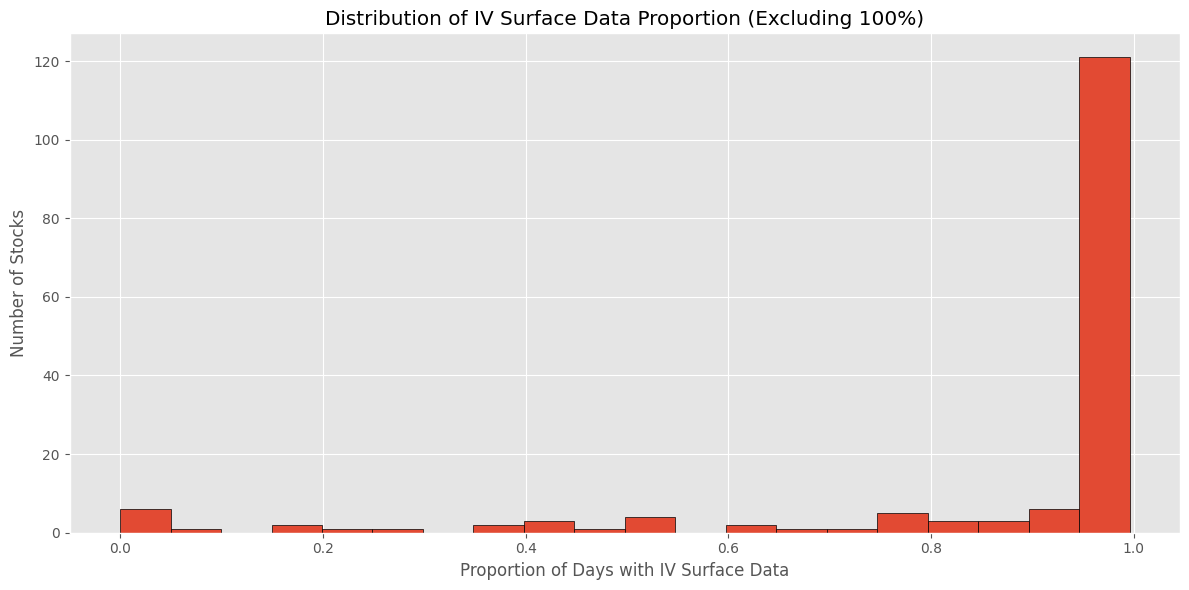

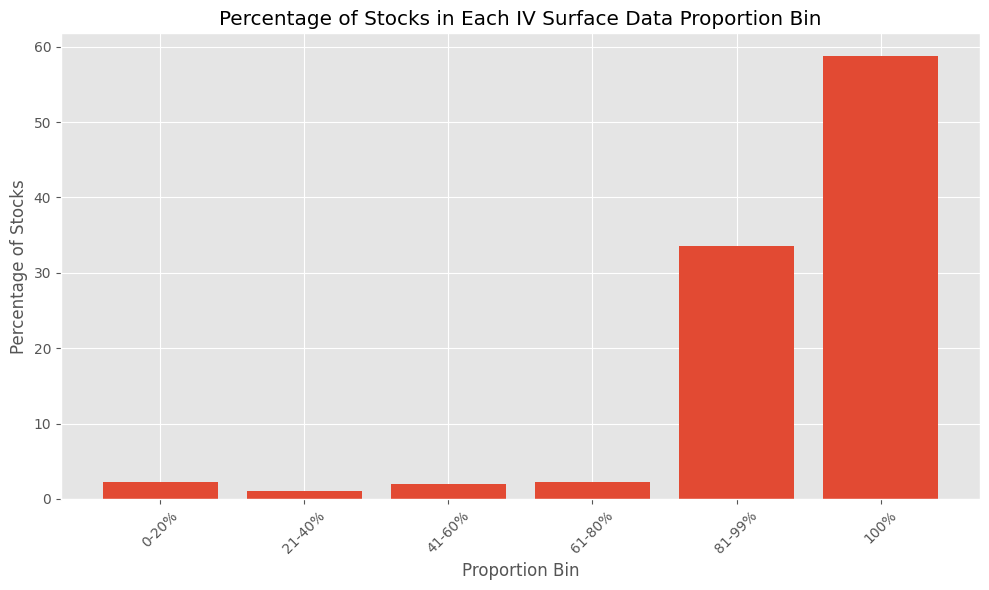

In [4]:
iv_surf_query = (
    session.query(
        Securities.ticker,
        func.count(distinct(IvSurf.exch_time)).label('days_with_iv_surf'),
        func.count(distinct(HistPrice1D.exch_time)).label('total_trading_days')
    )
    .join(IvSurf, Securities.ticker == IvSurf.ticker, isouter=True)
    .join(HistPrice1D, Securities.ticker == HistPrice1D.ticker)
    .filter(Securities.security_type == 'stk')
    .group_by(Securities.ticker)
)

iv_surf_df = pd.read_sql(iv_surf_query.statement, session.bind)

# Calculate the proportion of days with IV surface data
iv_surf_df['iv_surf_proportion'] = iv_surf_df['days_with_iv_surf'] / iv_surf_df['total_trading_days']

print("\n2. IV Surface Data Analysis:")

# Focus on stocks with incomplete data
incomplete_data = iv_surf_df[iv_surf_df['iv_surf_proportion'] < 1]
print("\nDescriptive Statistics of Stocks with Incomplete IV Surface Data:")
print(incomplete_data['iv_surf_proportion'].describe())

print(f"\nNumber of stocks with complete IV surface data: {(iv_surf_df['iv_surf_proportion'] == 1).sum()}")
print(f"Number of stocks with incomplete IV surface data: {len(incomplete_data)}")

print("\nBottom 20 Stocks with Lowest Proportion of IV Surface Data:")
print(iv_surf_df.nsmallest(20, 'iv_surf_proportion')[['ticker', 'iv_surf_proportion']])

# Create bins for proportion values
bins = [0, 0.2, 0.4, 0.6, 0.8, 0.99, 1]
labels = ['0-20%', '21-40%', '41-60%', '61-80%', '81-99%', '100%']
iv_surf_df['proportion_bin'] = pd.cut(iv_surf_df['iv_surf_proportion'], bins=bins, labels=labels, include_lowest=True)

print("\nDistribution of stocks across IV surface data proportion bins:")
print(iv_surf_df['proportion_bin'].value_counts().sort_index())

# Visualizations
plt.figure(figsize=(12, 6))
plt.hist(incomplete_data['iv_surf_proportion'], bins=20, edgecolor='black')
plt.title('Distribution of IV Surface Data Proportion (Excluding 100%)')
plt.xlabel('Proportion of Days with IV Surface Data')
plt.ylabel('Number of Stocks')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
bin_counts = iv_surf_df['proportion_bin'].value_counts().sort_index()
plt.bar(bin_counts.index, bin_counts.values / len(iv_surf_df) * 100)
plt.title('Percentage of Stocks in Each IV Surface Data Proportion Bin')
plt.xlabel('Proportion Bin')
plt.ylabel('Percentage of Stocks')
plt.xticks(rotation=45)
plt.tight_layout()
plt.tight_layout()
plt.show()


3. News Sentiment Distribution:
count    151030.000000
mean         65.400146
std          17.057170
min          10.000000
25%          50.000000
50%          75.000000
75%          75.000000
max         100.000000
Name: sentiment, dtype: float64


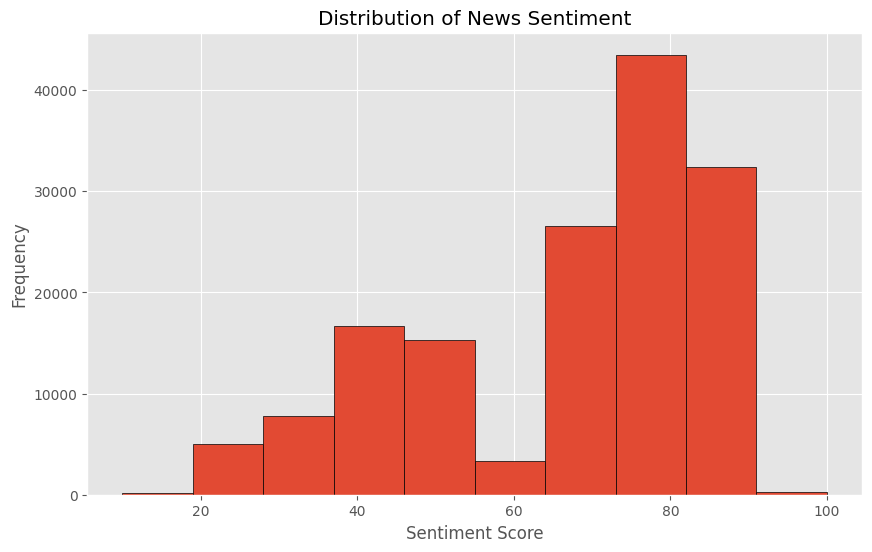

In [5]:
# 3. News data analysis
news_query = (
    session.query(News, NewsSecurities, Securities)
    .select_from(News)
    .join(NewsSecurities, News.id == NewsSecurities.news_id)
    .join(Securities, NewsSecurities.ticker == Securities.ticker)
)
df = pd.read_sql(news_query.statement, session.bind)

print("3. News Sentiment Distribution:")
print(df['sentiment'].describe())

# Plot
plt.figure(figsize=(10, 6))
df['sentiment'].hist(bins=10, edgecolor='black')
plt.title('Distribution of News Sentiment')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()

4. Top 10 Most Mentioned Tickers:
ticker
NVDA    4910
TSLA    4215
BA      2849
INTC    2368
META    2358
AMD     2273
AMZN    2197
PLTR    1679
SMCI    1633
TSM     1596
Name: count, dtype: int64


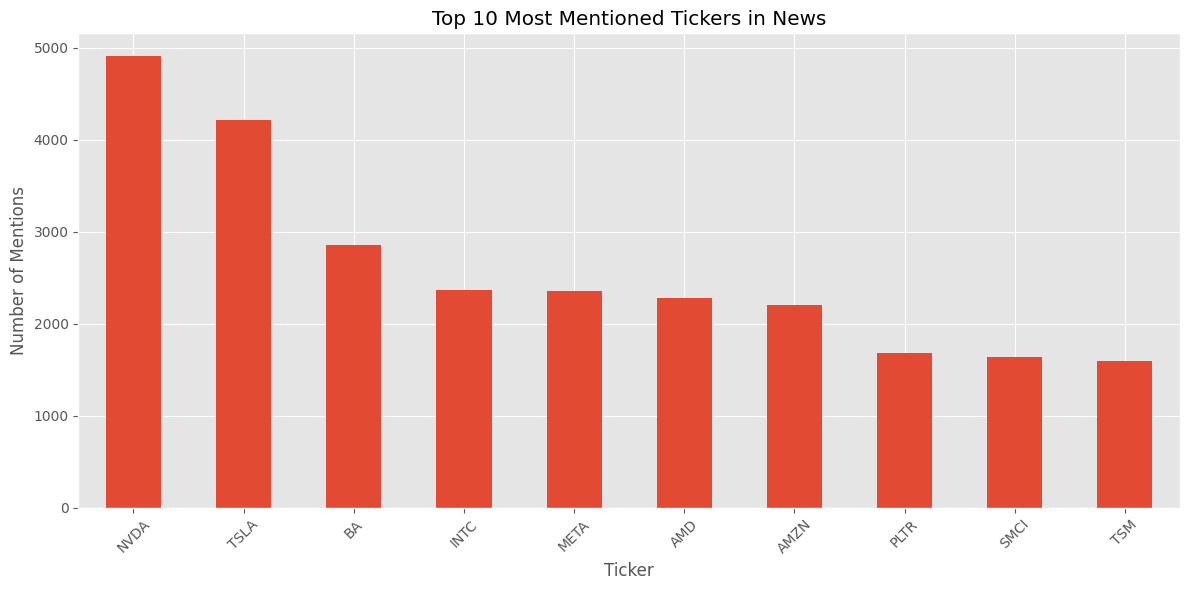

In [178]:
# 4. Top 10 most mentioned tickers in news
top_tickers = df['ticker'].value_counts().head(10)
print("4. Top 10 Most Mentioned Tickers:")
print(top_tickers)

# Plot
plt.figure(figsize=(12, 6))
top_tickers.plot(kind='bar')
plt.title('Top 10 Most Mentioned Tickers in News')
plt.xlabel('Ticker')
plt.ylabel('Number of Mentions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

5. Average Sentiment for Top 10 Most Mentioned Tickers:
ticker
NVDA    71.312487
PLTR    70.217391
TSM     69.593358
SMCI    67.493873
AMZN    67.059654
AMD     65.586268
META    63.729741
INTC    56.865173
TSLA    53.724555
BA      47.836083
Name: sentiment, dtype: float64


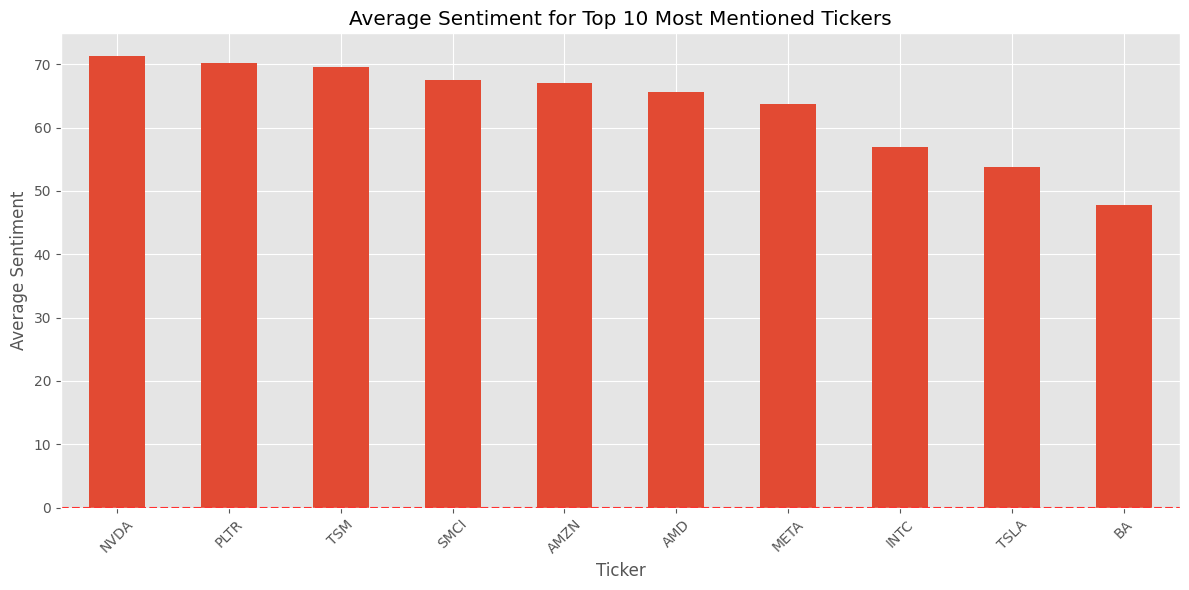

In [179]:
# 5. Average sentiment for top 10 most mentioned tickers
top_10_tickers = top_tickers.index
avg_sentiment = df[df['ticker'].isin(top_10_tickers)].groupby('ticker')['sentiment'].mean().sort_values(ascending=False)
print("5. Average Sentiment for Top 10 Most Mentioned Tickers:")
print(avg_sentiment)

# Plot
plt.figure(figsize=(12, 6))
avg_sentiment.plot(kind='bar')
plt.title('Average Sentiment for Top 10 Most Mentioned Tickers')
plt.xlabel('Ticker')
plt.ylabel('Average Sentiment')
plt.axhline(y=0, color='r', linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

6. Average News Volume by Day of the Week:
day_of_week
Monday       160.077617
Tuesday      191.697653
Wednesday    203.138989
Thursday     199.980144
Friday       121.621841
Saturday      36.269856
Sunday        41.924188
dtype: float64


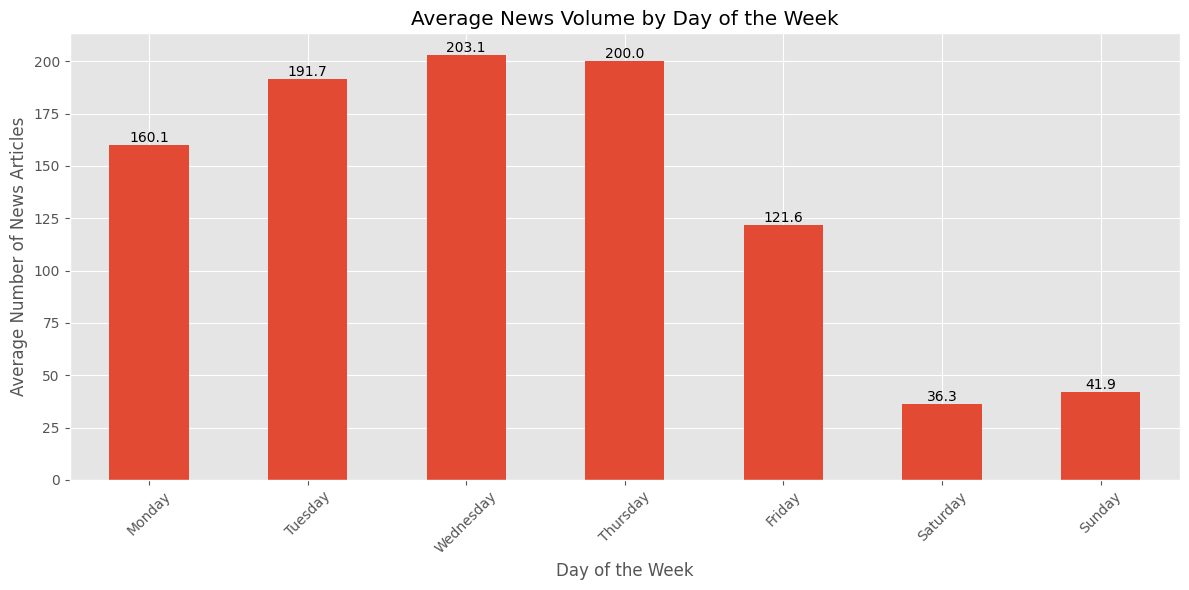

In [180]:
# 6. News volume by day of the week
df['date'] = pd.to_datetime(df['published_utc'])
df['day_of_week'] = df['date'].dt.day_name()

# Calculate average news volume for each day of the week
news_volume_by_day = df.groupby('day_of_week').size().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
news_volume_by_day = news_volume_by_day / (df['date'].max() - df['date'].min()).days * 7  # Convert to daily average

print("6. Average News Volume by Day of the Week:")
print(news_volume_by_day)

# Plot
plt.figure(figsize=(12, 6))
bars = news_volume_by_day.plot(kind='bar')
plt.title('Average News Volume by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Number of News Articles')
plt.xticks(rotation=45)

# Add value labels on top of each bar
for i, v in enumerate(news_volume_by_day):
    plt.text(i, v, f'{v:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

7. Descriptive Stats of Related Tickers per News Article:
count    122532.000000
mean          1.233286
std           0.670160
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          32.000000
Name: ticker, dtype: float64


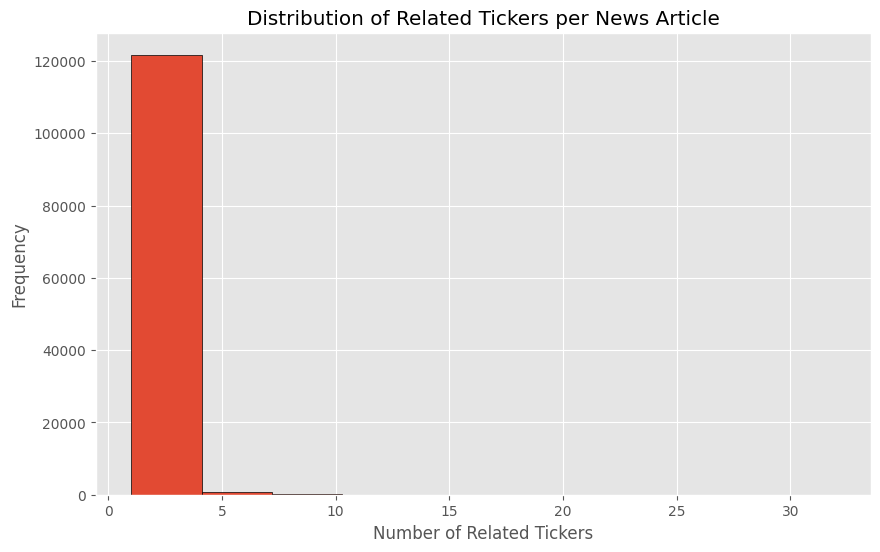

In [181]:
# 7. Descriptive stats about related tickers per news
tickers_per_news = df.groupby('id')['ticker'].count()
print("7. Descriptive Stats of Related Tickers per News Article:")
print(tickers_per_news.describe())

# Plot
plt.figure(figsize=(10, 6))
tickers_per_news.hist(bins=10, edgecolor='black')
plt.title('Distribution of Related Tickers per News Article')
plt.xlabel('Number of Related Tickers')
plt.ylabel('Frequency')
plt.show()

8. Analysis of News-Ticker Pairs With and Without Sentiment Scores:
Total number of news-ticker pairs: 151117
Number of news-ticker pairs with sentiment scores: 151030
Number of news-ticker pairs without sentiment scores: 87


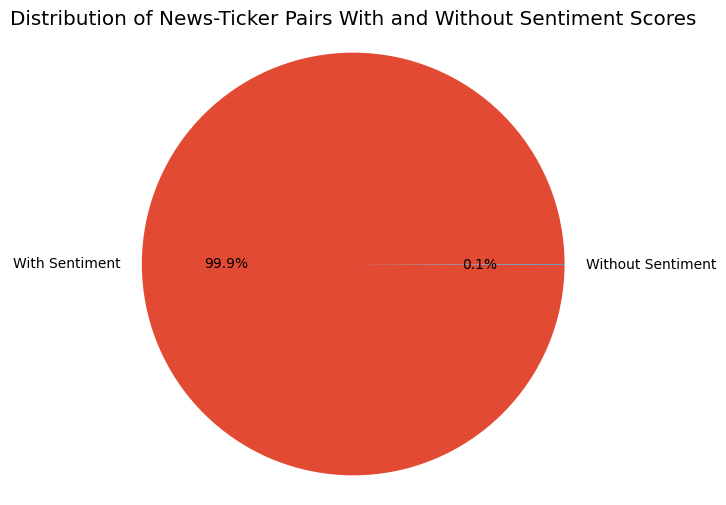

In [182]:
# 8. Analysis of news-ticker pairs with and without sentiment scores
print("8. Analysis of News-Ticker Pairs With and Without Sentiment Scores:")
total_pairs = len(df)
with_sentiment = df['sentiment'].notnull().sum()
without_sentiment = df['sentiment'].isnull().sum()

print(f"Total number of news-ticker pairs: {total_pairs}")
print(f"Number of news-ticker pairs with sentiment scores: {with_sentiment}")
print(f"Number of news-ticker pairs without sentiment scores: {without_sentiment}")

# Plot
plt.figure(figsize=(6, 6))
plt.pie([with_sentiment, without_sentiment], labels=['With Sentiment', 'Without Sentiment'], autopct='%1.1f%%')
plt.title('Distribution of News-Ticker Pairs With and Without Sentiment Scores')
plt.axis('equal')
plt.show()

# Close the session
session.close()

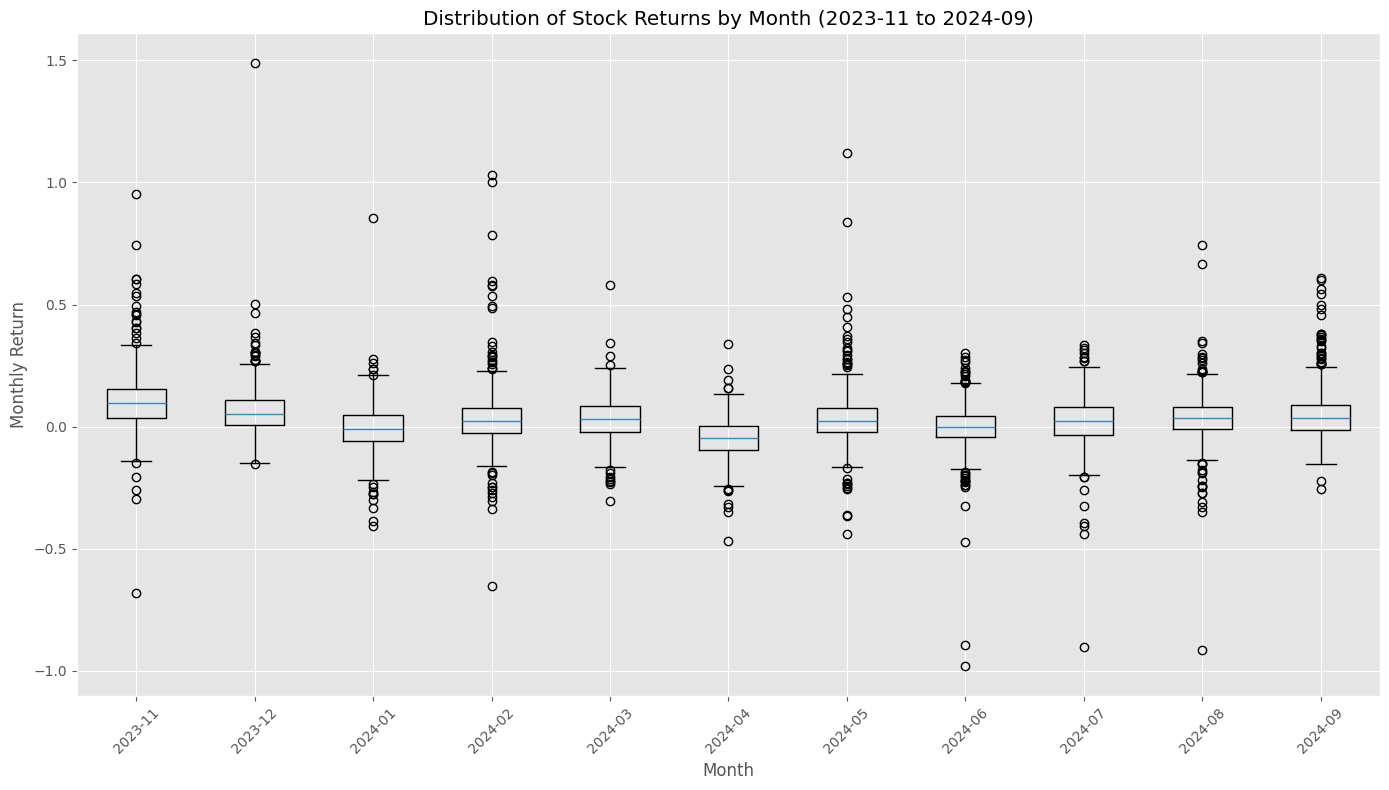


Summary Statistics of Monthly Stock Returns:
         count      mean       std       min       25%       50%       75%  \
month                                                                        
2023-11  391.0  0.105660  0.139045 -0.681054  0.035296  0.095310  0.156112   
2023-12  391.0  0.068995  0.116991 -0.152935  0.006200  0.051147  0.110149   
2024-01  391.0 -0.010962  0.105014 -0.406695 -0.059679 -0.011247  0.048291   
2024-02  391.0  0.038941  0.145399 -0.651774 -0.024835  0.022666  0.078051   
2024-03  391.0  0.029662  0.091981 -0.304548 -0.019810  0.032807  0.085055   
2024-04  391.0 -0.049705  0.084720 -0.469979 -0.096635 -0.046477  0.001553   
2024-05  391.0  0.035330  0.131209 -0.440786 -0.023171  0.023399  0.074653   
2024-06  391.0 -0.005091  0.111664 -0.979636 -0.044088 -0.001585  0.045471   
2024-07  391.0  0.021241  0.112895 -0.902072 -0.032382  0.024591  0.078865   
2024-08  391.0  0.034440  0.115853 -0.912410 -0.011539  0.035694  0.079221   
2024-09  391.0  0.

In [156]:
# New query to get stock prices for return calculation
stock_prices_query = (
    session.query(
        HistPrice1D.ticker,
        HistPrice1D.exch_time,
        HistPrice1D.close
    )
    .join(Securities, HistPrice1D.ticker == Securities.ticker)
    .filter(Securities.security_type == 'stk')
    .filter(HistPrice1D.exch_time >= '2023-11-01')
    .filter(HistPrice1D.exch_time <= '2024-09-30')
)

stock_prices_df = pd.read_sql(stock_prices_query.statement, session.bind)

# Convert exch_time to datetime
stock_prices_df['exch_time'] = pd.to_datetime(stock_prices_df['exch_time'])

# Calculate monthly returns
stock_prices_df['month'] = stock_prices_df['exch_time'].dt.to_period('M')
monthly_returns = stock_prices_df.groupby(['ticker', 'month'])['close'].agg(['first', 'last'])
monthly_returns['return'] = (monthly_returns['last'] - monthly_returns['first']) / monthly_returns['first']

# Prepare data for box plot
box_plot_data = [monthly_returns.loc[monthly_returns.index.get_level_values('month') == month, 'return'] 
                 for month in pd.period_range(start='2023-11', end='2024-09', freq='M')]

# Create box plot
plt.figure(figsize=(14, 8))
plt.boxplot(box_plot_data, tick_labels=[month.strftime('%Y-%m') for month in pd.period_range(start='2023-11', end='2024-09', freq='M')])
plt.title('Distribution of Stock Returns by Month (2023-11 to 2024-09)')
plt.xlabel('Month')
plt.ylabel('Monthly Return')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics of Monthly Stock Returns:")
print(monthly_returns.groupby('month')['return'].describe())


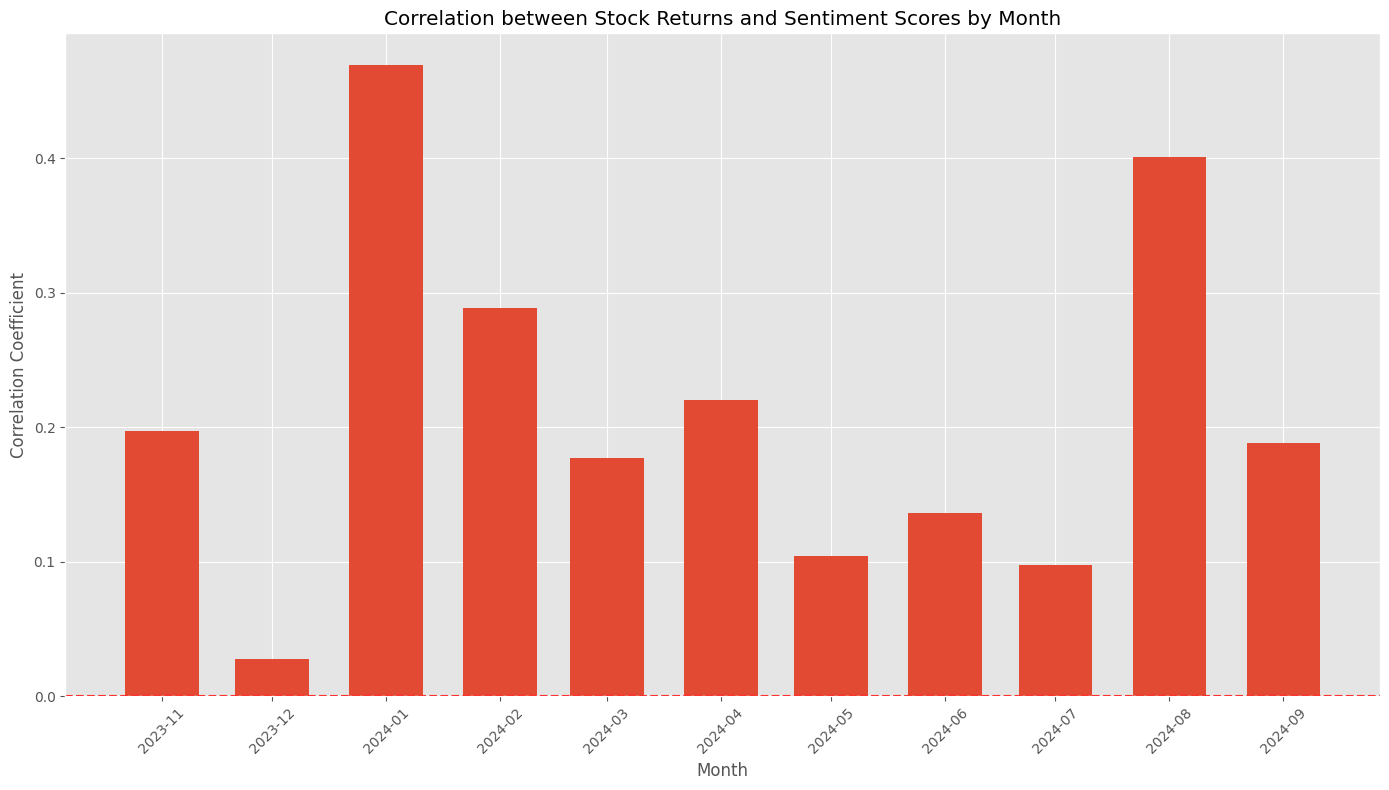


Correlation between Stock Returns and Sentiment Scores by Month:
2023-11: 0.1971
2023-12: 0.0273
2024-01: 0.4694
2024-02: 0.2886
2024-03: 0.1767
2024-04: 0.2198
2024-05: 0.1040
2024-06: 0.1358
2024-07: 0.0973
2024-08: 0.4005
2024-09: 0.1881


In [157]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sqlalchemy import func
from scipy.stats import pearsonr
plt.style.use('ggplot')

# Query to get stock prices for return calculation
stock_prices_query = (
    session.query(
        HistPrice1D.ticker,
        HistPrice1D.exch_time,
        HistPrice1D.close
    )
    .join(Securities, HistPrice1D.ticker == Securities.ticker)
    .filter(Securities.security_type == 'stk')
    .filter(HistPrice1D.exch_time >= '2023-11-01')
    .filter(HistPrice1D.exch_time <= '2024-09-30')
)

stock_prices_df = pd.read_sql(stock_prices_query.statement, session.bind)

# Convert exch_time to datetime
stock_prices_df['exch_time'] = pd.to_datetime(stock_prices_df['exch_time'])

# Calculate monthly returns
stock_prices_df['month'] = stock_prices_df['exch_time'].dt.to_period('M')
monthly_returns = stock_prices_df.groupby(['ticker', 'month'])['close'].agg(['first', 'last'])
monthly_returns['return'] = (monthly_returns['last'] - monthly_returns['first']) / monthly_returns['first']

# Query to get sentiment scores
sentiment_query = (
    session.query(
        NewsSecurities.ticker,
        News.published_utc,
        NewsSecurities.sentiment
    )
    .join(News, NewsSecurities.news_id == News.id)
    .filter(News.published_utc >= '2023-11-01')
    .filter(News.published_utc <= '2024-09-30')
    .filter(News.content.isnot(None))
)

sentiment_df = pd.read_sql(sentiment_query.statement, session.bind)

# Convert published_utc to datetime and create month column
sentiment_df['published_utc'] = pd.to_datetime(sentiment_df['published_utc'])
sentiment_df['month'] = sentiment_df['published_utc'].dt.to_period('M')

# Calculate average sentiment per stock per month
monthly_sentiment = sentiment_df.groupby(['ticker', 'month'])['sentiment'].mean().reset_index()

# Merge returns and sentiment data
merged_data = pd.merge(monthly_returns.reset_index(), monthly_sentiment, on=['ticker', 'month'], how='inner')

# Print data availability
# print("\nData availability by month:")
# print(merged_data.groupby('month').size())

# Calculate correlation for each month
correlations = []
months = pd.period_range(start='2023-11', end='2024-09', freq='M')

for month in months:
    month_data = merged_data[merged_data['month'] == month]
    if len(month_data) > 1:  # Ensure we have enough data points
        returns = month_data['return']
        sentiments = month_data['sentiment']
        
        # Check for non-null values
        valid_mask = ~(returns.isnull() | sentiments.isnull())
        valid_returns = returns[valid_mask]
        valid_sentiments = sentiments[valid_mask]
        
        if len(valid_returns) > 1:
            corr, _ = pearsonr(valid_returns, valid_sentiments)
            correlations.append((month.to_timestamp(), corr))
        else:
            print(f"Insufficient valid data for {month}")
            print(f"Total data points: {len(month_data)}")
            print(f"Valid data points: {len(valid_returns)}")
            print(f"Sample of invalid data:")
            print(month_data[~valid_mask].head())
    else:
        print(f"Insufficient data for {month}")

# Create correlation plot
plt.figure(figsize=(14, 8))
months, corrs = zip(*correlations)
plt.bar(months, corrs, width=20)  # width in days
plt.title('Correlation between Stock Returns and Sentiment Scores by Month')
plt.xlabel('Month')
plt.ylabel('Correlation Coefficient')
plt.xticks(months, [m.strftime('%Y-%m') for m in months], rotation=45)
plt.axhline(y=0, color='r', linestyle='--')
plt.tight_layout()
plt.show()

# Print correlation values
print("\nCorrelation between Stock Returns and Sentiment Scores by Month:")
for month, corr in correlations:
    print(f"{month.strftime('%Y-%m')}: {corr:.4f}")


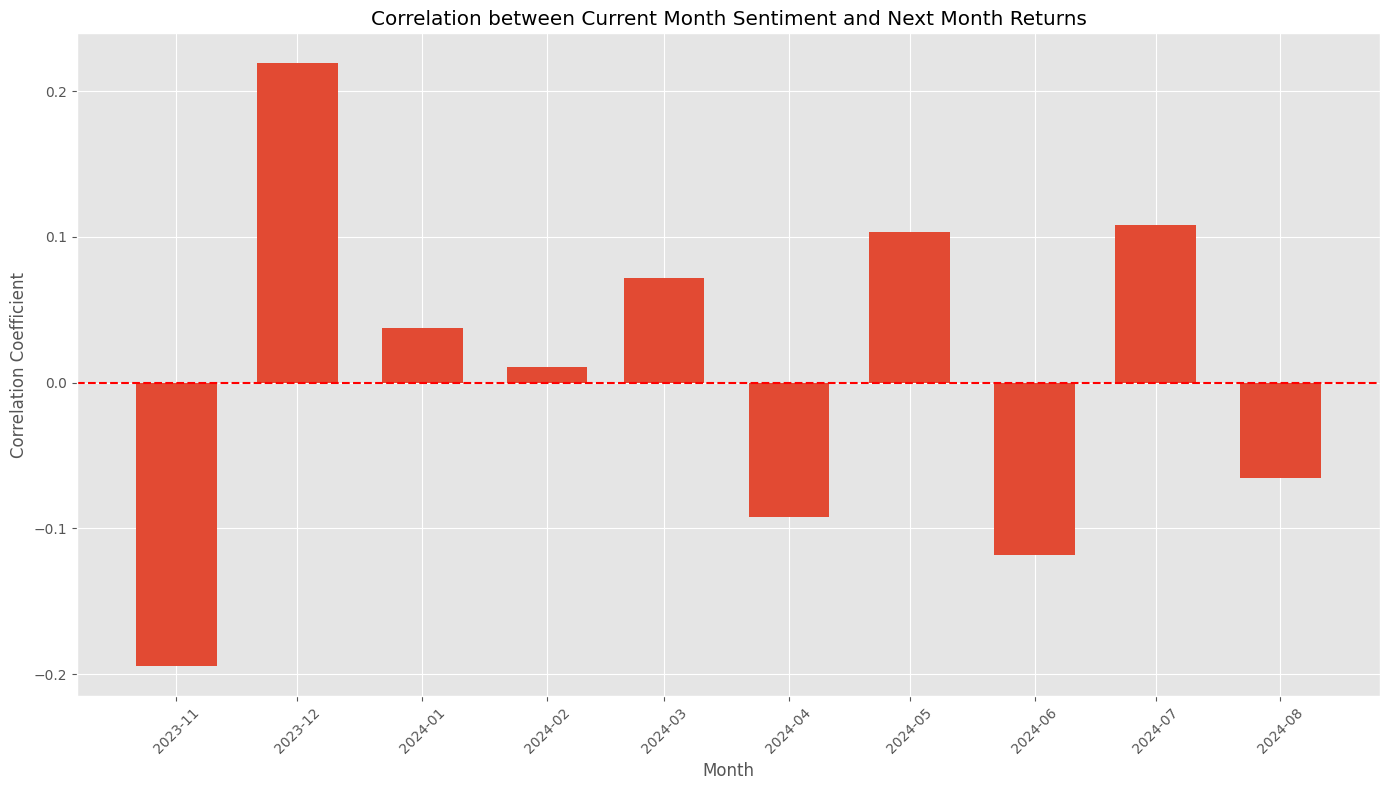


Correlation between Current Month Sentiment and Next Month Returns:
2023-11: -0.1944
2023-12: 0.2190
2024-01: 0.0373
2024-02: 0.0110
2024-03: 0.0718
2024-04: -0.0919
2024-05: 0.1035
2024-06: -0.1183
2024-07: 0.1082
2024-08: -0.0657


In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sqlalchemy import func
from scipy.stats import pearsonr
plt.style.use('ggplot')

# ... (previous code remains the same)

# Query to get stock prices for return calculation
stock_prices_query = (
    session.query(
        HistPrice1D.ticker,
        HistPrice1D.exch_time,
        HistPrice1D.close
    )
    .join(Securities, HistPrice1D.ticker == Securities.ticker)
    .filter(Securities.security_type == 'stk')
    .filter(HistPrice1D.exch_time >= '2023-11-01')
    .filter(HistPrice1D.exch_time <= '2024-09-30')
)

stock_prices_df = pd.read_sql(stock_prices_query.statement, session.bind)

# Convert exch_time to datetime
stock_prices_df['exch_time'] = pd.to_datetime(stock_prices_df['exch_time'])

# Calculate monthly returns
stock_prices_df['month'] = stock_prices_df['exch_time'].dt.to_period('M')
monthly_returns = stock_prices_df.groupby(['ticker', 'month'])['close'].agg(['first', 'last'])
monthly_returns['return'] = (monthly_returns['last'] - monthly_returns['first']) / monthly_returns['first']

# Query to get sentiment scores
sentiment_query = (
    session.query(
        NewsSecurities.ticker,
        News.published_utc,
        NewsSecurities.sentiment
    )
    .join(News, NewsSecurities.news_id == News.id)
    .filter(News.published_utc >= '2023-11-01')
    .filter(News.published_utc <= '2024-09-30')
    .filter(News.content.isnot(None))
)

sentiment_df = pd.read_sql(sentiment_query.statement, session.bind)

# Convert published_utc to datetime and create month column
sentiment_df['published_utc'] = pd.to_datetime(sentiment_df['published_utc'])
sentiment_df['month'] = sentiment_df['published_utc'].dt.to_period('M')

# Calculate average sentiment per stock per month
monthly_sentiment = sentiment_df.groupby(['ticker', 'month'])['sentiment'].mean().reset_index()

# Calculate next month's returns
monthly_returns = monthly_returns.reset_index()
monthly_returns['next_month'] = monthly_returns['month'] + pd.offsets.MonthEnd(1)
monthly_returns['next_month_return'] = monthly_returns.groupby('ticker')['return'].shift(-1)

# Merge returns and sentiment data
merged_data = pd.merge(monthly_returns, monthly_sentiment, on=['ticker', 'month'], how='inner')

# Calculate correlation for each month (current sentiment vs next month return)
correlations_next_month = []
months = pd.period_range(start='2023-11', end='2024-08', freq='M')  # Note: end is now 2024-08

for month in months:
    month_data = merged_data[merged_data['month'] == month]
    if len(month_data) > 1:  # Ensure we have enough data points
        sentiments = month_data['sentiment']
        next_returns = month_data['next_month_return']
        
        # Check for non-null values
        valid_mask = ~(next_returns.isnull() | sentiments.isnull())
        valid_sentiments = sentiments[valid_mask]
        valid_next_returns = next_returns[valid_mask]
        
        if len(valid_sentiments) > 1:
            corr, _ = pearsonr(valid_sentiments, valid_next_returns)
            correlations_next_month.append((month.to_timestamp(), corr))
        else:
            print(f"Insufficient valid data for {month} (next month prediction)")
    else:
        print(f"Insufficient data for {month} (next month prediction)")

# Create correlation plot for next month prediction
plt.figure(figsize=(14, 8))
months, corrs = zip(*correlations_next_month)
plt.bar(months, corrs, width=20)  # width in days
plt.title('Correlation between Current Month Sentiment and Next Month Returns')
plt.xlabel('Month')
plt.ylabel('Correlation Coefficient')
plt.xticks(months, [m.strftime('%Y-%m') for m in months], rotation=45)
plt.axhline(y=0, color='r', linestyle='--')
plt.tight_layout()
plt.show()

# Print correlation values for next month prediction
print("\nCorrelation between Current Month Sentiment and Next Month Returns:")
for month, corr in correlations_next_month:
    print(f"{month.strftime('%Y-%m')}: {corr:.4f}")

In [1]:
import numpy as np
from scipy import stats

# Correlation values
correlations = [-0.1991, 0.2356, 0.0254, 0.0469, 0.0593, -0.1150, 0.1065, -0.1218, 0.1260, -0.0758]

# Calculate basic statistics
mean_correlation = np.mean(correlations)
std_correlation = np.std(correlations, ddof=1)  # ddof=1 for sample standard deviation
n = len(correlations)

# Perform one-sided t-test (H0: mean <= 0, H1: mean > 0)
t_stat, p_value = stats.ttest_1samp(correlations, 0)
# Since we want one-sided test, divide p-value by 2 (but only if t-stat is positive)
one_sided_p_value = p_value / 2 if t_stat > 0 else 1 - p_value / 2

print(f"Mean correlation: {mean_correlation:.4f}")
print(f"Standard deviation: {std_correlation:.4f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"One-sided p-value: {one_sided_p_value:.4f}")
print("\nNull Hypothesis: Mean correlation ≤ 0")
print("Alternative Hypothesis: Mean correlation > 0")
print(f"\nConclusion: {'Reject' if one_sided_p_value < 0.05 else 'Fail to reject'} the null hypothesis at 5% significance level")

Mean correlation: 0.0088
Standard deviation: 0.1341
t-statistic: 0.2076
One-sided p-value: 0.4201

Null Hypothesis: Mean correlation ≤ 0
Alternative Hypothesis: Mean correlation > 0

Conclusion: Fail to reject the null hypothesis at 5% significance level



Initial data statistics:
Number of stocks with returns: 392
Number of months: 11

Before merging:
Number of stocks with sentiment scores: 381
Number of months in sentiment data: 11

After merging:
Number of stocks in final dataset: 381
Number of months in final dataset: 11

Missing values in merged data:
ticker        0
month         0
first         0
last          0
return        0
sentiment     4
spy_return    0
dtype: int64

After removing NaN values:
Final number of observations: 3290
Final number of stocks: 381
Final number of months: 11

Regression Results:
Coefficients: SPY Return: 1.1796, Sentiment: 0.0030
Intercept: -0.2122

In-sample (Training) Performance:
R-squared: 0.1196
RMSE: 0.1142

Out-of-sample (Testing) Performance:
R-squared: 0.1307
RMSE: 0.1200


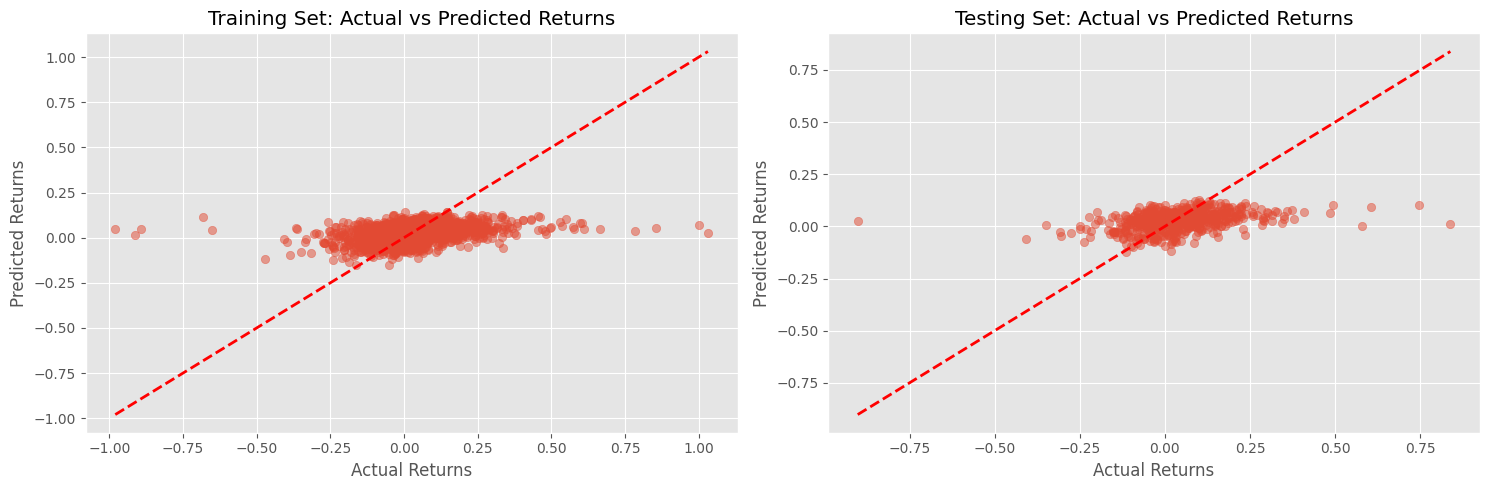


Feature Statistics:
            return   spy_return    sentiment
count  3290.000000  3290.000000  3290.000000
mean      0.030740     0.029574    67.881541
std       0.123228     0.028178     8.428405
min      -0.979636    -0.038647    25.000000
25%      -0.032052     0.019928    63.200000
50%       0.025292     0.035308    69.377717
75%       0.084660     0.039270    73.947013
max       1.031540     0.079828    85.000000


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sqlalchemy import func
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
plt.style.use('ggplot')

# Query to get stock prices for return calculation (including SPY)
stock_prices_query = (
    session.query(
        HistPrice1D.ticker,
        HistPrice1D.exch_time,
        HistPrice1D.close
    )
    .join(Securities, HistPrice1D.ticker == Securities.ticker)
    .filter(Securities.security_type == 'stk')
    .filter(HistPrice1D.exch_time >= '2023-11-01')
    .filter(HistPrice1D.exch_time <= '2024-09-30')
)

stock_prices_df = pd.read_sql(stock_prices_query.statement, session.bind)

# Convert exch_time to datetime
stock_prices_df['exch_time'] = pd.to_datetime(stock_prices_df['exch_time'])
stock_prices_df['month'] = stock_prices_df['exch_time'].dt.to_period('M')

# Calculate monthly returns for all stocks including SPY
monthly_returns = stock_prices_df.groupby(['ticker', 'month'])['close'].agg(['first', 'last'])
monthly_returns['return'] = (monthly_returns['last'] - monthly_returns['first']) / monthly_returns['first']
monthly_returns = monthly_returns.reset_index()

# Print initial data stats
print("\nInitial data statistics:")
print(f"Number of stocks with returns: {monthly_returns['ticker'].nunique()}")
print(f"Number of months: {monthly_returns['month'].nunique()}")

# Separate SPY returns
spy_returns = monthly_returns[monthly_returns['ticker'] == 'SPY'][['month', 'return']]
spy_returns = spy_returns.rename(columns={'return': 'spy_return'})

# Get returns for other stocks
stock_returns = monthly_returns[monthly_returns['ticker'] != 'SPY']

# Query to get sentiment scores (excluding SPY)
sentiment_query = (
    session.query(
        NewsSecurities.ticker,
        News.published_utc,
        NewsSecurities.sentiment
    )
    .join(News, NewsSecurities.news_id == News.id)
    .filter(News.published_utc >= '2023-11-01')
    .filter(News.published_utc <= '2024-09-30')
    .filter(News.content.isnot(None))
    .filter(NewsSecurities.ticker != 'SPY')
)

sentiment_df = pd.read_sql(sentiment_query.statement, session.bind)

# Convert published_utc to datetime and create month column
sentiment_df['published_utc'] = pd.to_datetime(sentiment_df['published_utc'])
sentiment_df['month'] = sentiment_df['published_utc'].dt.to_period('M')

# Calculate average sentiment per stock per month
monthly_sentiment = sentiment_df.groupby(['ticker', 'month'])['sentiment'].mean().reset_index()

print("\nBefore merging:")
print(f"Number of stocks with sentiment scores: {monthly_sentiment['ticker'].nunique()}")
print(f"Number of months in sentiment data: {monthly_sentiment['month'].nunique()}")

# Merge all data
merged_data = pd.merge(stock_returns, monthly_sentiment, on=['ticker', 'month'], how='inner')
merged_data = pd.merge(merged_data, spy_returns, on=['month'], how='inner')

print("\nAfter merging:")
print(f"Number of stocks in final dataset: {merged_data['ticker'].nunique()}")
print(f"Number of months in final dataset: {merged_data['month'].nunique()}")
print("\nMissing values in merged data:")
print(merged_data.isnull().sum())

# Remove any remaining NaN values
merged_data = merged_data.dropna()

print("\nAfter removing NaN values:")
print(f"Final number of observations: {len(merged_data)}")
print(f"Final number of stocks: {merged_data['ticker'].nunique()}")
print(f"Final number of months: {merged_data['month'].nunique()}")

# Prepare features (X) and target (y)
X = merged_data[['spy_return', 'sentiment']]
y = merged_data['return']

# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate performance metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Print results
print("\nRegression Results:")
print(f"Coefficients: SPY Return: {model.coef_[0]:.4f}, Sentiment: {model.coef_[1]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print("\nIn-sample (Training) Performance:")
print(f"R-squared: {train_r2:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print("\nOut-of-sample (Testing) Performance:")
print(f"R-squared: {test_r2:.4f}")
print(f"RMSE: {test_rmse:.4f}")

# Create scatter plots
plt.figure(figsize=(15, 5))

# Training set predictions
plt.subplot(121)
plt.scatter(y_train, y_train_pred, alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual Returns')
plt.ylabel('Predicted Returns')
plt.title('Training Set: Actual vs Predicted Returns')

# Testing set predictions
plt.subplot(122)
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Returns')
plt.ylabel('Predicted Returns')
plt.title('Testing Set: Actual vs Predicted Returns')

plt.tight_layout()
plt.show()

# Print feature statistics
print("\nFeature Statistics:")
print(merged_data[['return', 'spy_return', 'sentiment']].describe())


Regression Results Summary:
Number of stocks analyzed: 279

Average Metrics Across All Stocks:
Average SPY Beta: 1.2303
Average Sentiment Beta: 0.0010
Average Training R2: 0.2301
Average Testing R2: -0.4136
Average Training RMSE: 0.0417
Average Testing RMSE: 0.0463
Average Number of Observations: 36.7


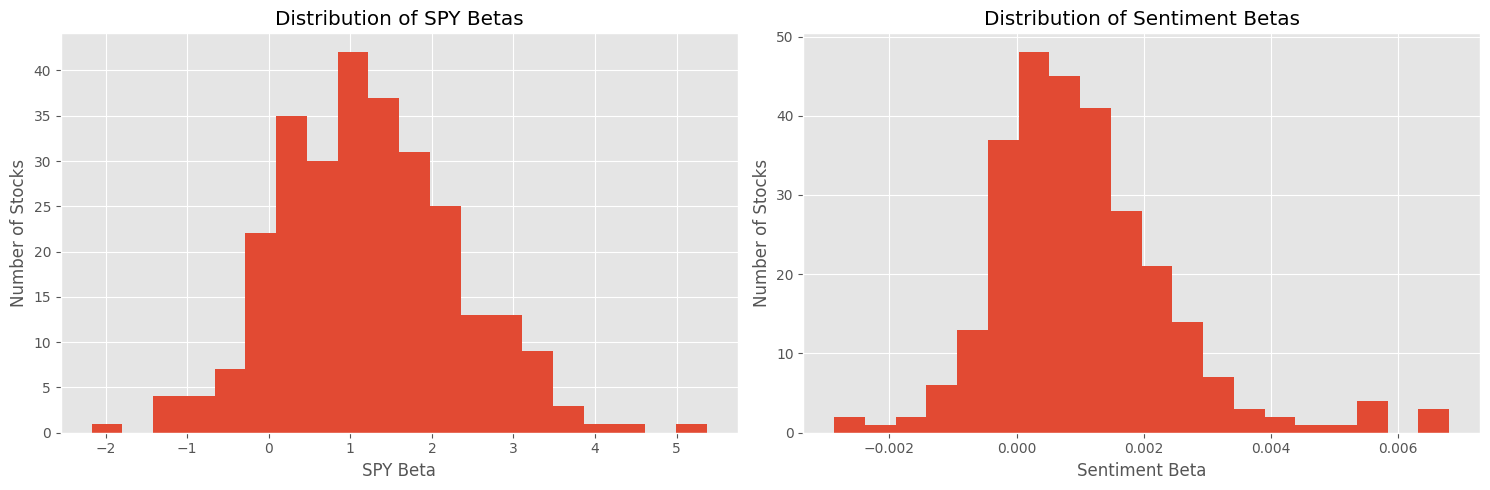


Top 10 Stocks by Test R2:

BBIO:
SPY Beta: -2.1707
Sentiment Beta: -0.0010
Test R2: 0.8903
Number of observations: 20

KLAC:
SPY Beta: 2.7864
Sentiment Beta: 0.0002
Test R2: 0.8524
Number of observations: 30

LRCX:
SPY Beta: 2.7639
Sentiment Beta: -0.0005
Test R2: 0.7083
Number of observations: 47

NOW:
SPY Beta: 0.5805
Sentiment Beta: 0.0018
Test R2: 0.7044
Number of observations: 47

TSM:
SPY Beta: 1.9889
Sentiment Beta: 0.0000
Test R2: 0.6837
Number of observations: 48

QCOM:
SPY Beta: 2.3321
Sentiment Beta: 0.0007
Test R2: 0.6627
Number of observations: 48

AMAT:
SPY Beta: 2.2944
Sentiment Beta: 0.0010
Test R2: 0.6316
Number of observations: 48

RACE:
SPY Beta: 1.3330
Sentiment Beta: 0.0008
Test R2: 0.6197
Number of observations: 21

ASML:
SPY Beta: 2.4980
Sentiment Beta: 0.0007
Test R2: 0.6126
Number of observations: 48

COHR:
SPY Beta: 4.1578
Sentiment Beta: 0.0004
Test R2: 0.6098
Number of observations: 29


In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sqlalchemy import func
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
plt.style.use('ggplot')

# Query to get stock prices for return calculation (including SPY)
stock_prices_query = (
    session.query(
        HistPrice1D.ticker,
        HistPrice1D.exch_time,
        HistPrice1D.close
    )
    .join(Securities, HistPrice1D.ticker == Securities.ticker)
    .filter(Securities.security_type == 'stk')
    .filter(HistPrice1D.exch_time >= '2023-11-01')
    .filter(HistPrice1D.exch_time <= '2024-09-30')
)

stock_prices_df = pd.read_sql(stock_prices_query.statement, session.bind)

# Convert exch_time to datetime
stock_prices_df['exch_time'] = pd.to_datetime(stock_prices_df['exch_time'])
stock_prices_df['week'] = stock_prices_df['exch_time'].dt.to_period('W')

# Calculate weekly returns for all stocks including SPY
weekly_returns = stock_prices_df.groupby(['ticker', 'week'])['close'].agg(['first', 'last'])
weekly_returns['return'] = (weekly_returns['last'] - weekly_returns['first']) / weekly_returns['first']
weekly_returns = weekly_returns.reset_index()

# Separate SPY returns
spy_returns = weekly_returns[weekly_returns['ticker'] == 'SPY'][['week', 'return']]
spy_returns = spy_returns.rename(columns={'return': 'spy_return'})

# Query to get sentiment scores
sentiment_query = (
    session.query(
        NewsSecurities.ticker,
        News.published_utc,
        NewsSecurities.sentiment
    )
    .join(News, NewsSecurities.news_id == News.id)
    .filter(News.published_utc >= '2023-11-01')
    .filter(News.published_utc <= '2024-09-30')
    .filter(News.content.isnot(None))
)

sentiment_df = pd.read_sql(sentiment_query.statement, session.bind)

# Convert published_utc to datetime and create week column
sentiment_df['published_utc'] = pd.to_datetime(sentiment_df['published_utc'])
sentiment_df['week'] = sentiment_df['published_utc'].dt.to_period('W')

# Calculate average sentiment per stock per week
weekly_sentiment = sentiment_df.groupby(['ticker', 'week'])['sentiment'].mean().reset_index()

# Function to perform regression for a single stock
def perform_stock_regression(stock_data):
    # Prepare features (X) and target (y)
    X = stock_data[['spy_return', 'sentiment']]
    y = stock_data['return']
    
    # Split the data into training and testing sets (80-20 split)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Fit the model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate performance metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    return {
        'coefficients': model.coef_,
        'intercept': model.intercept_,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'n_observations': len(y)
    }

# Process each stock
results = {}
min_observations = 20  # Minimum number of weeks required for regression

for ticker in weekly_returns['ticker'].unique():
    if ticker == 'SPY':
        continue
        
    # Get data for this stock
    stock_returns = weekly_returns[weekly_returns['ticker'] == ticker]
    stock_sentiment = weekly_sentiment[weekly_sentiment['ticker'] == ticker]
    
    # Merge stock data with SPY returns and sentiment
    stock_data = pd.merge(stock_returns, spy_returns, on='week', how='inner')
    stock_data = pd.merge(stock_data, stock_sentiment, on=['ticker', 'week'], how='inner')
    
    # Remove any NaN values
    stock_data = stock_data.dropna()
    
    # Only perform regression if we have enough data points
    if len(stock_data) >= min_observations:
        results[ticker] = perform_stock_regression(stock_data)

# Print summary statistics
print("\nRegression Results Summary:")
print(f"Number of stocks analyzed: {len(results)}")

# Calculate average metrics across all stocks
avg_metrics = {
    'spy_beta': [],
    'sentiment_beta': [],
    'train_r2': [],
    'test_r2': [],
    'train_rmse': [],
    'test_rmse': [],
    'n_observations': []
}

for ticker, res in results.items():
    avg_metrics['spy_beta'].append(res['coefficients'][0])
    avg_metrics['sentiment_beta'].append(res['coefficients'][1])
    avg_metrics['train_r2'].append(res['train_r2'])
    avg_metrics['test_r2'].append(res['test_r2'])
    avg_metrics['train_rmse'].append(res['train_rmse'])
    avg_metrics['test_rmse'].append(res['test_rmse'])
    avg_metrics['n_observations'].append(res['n_observations'])

print("\nAverage Metrics Across All Stocks:")
print(f"Average SPY Beta: {np.mean(avg_metrics['spy_beta']):.4f}")
print(f"Average Sentiment Beta: {np.mean(avg_metrics['sentiment_beta']):.4f}")
print(f"Average Training R2: {np.mean(avg_metrics['train_r2']):.4f}")
print(f"Average Testing R2: {np.mean(avg_metrics['test_r2']):.4f}")
print(f"Average Training RMSE: {np.mean(avg_metrics['train_rmse']):.4f}")
print(f"Average Testing RMSE: {np.mean(avg_metrics['test_rmse']):.4f}")
print(f"Average Number of Observations: {np.mean(avg_metrics['n_observations']):.1f}")

# Create histograms of the coefficients
plt.figure(figsize=(15, 5))

plt.subplot(121)
plt.hist(avg_metrics['spy_beta'], bins=20)
plt.title('Distribution of SPY Betas')
plt.xlabel('SPY Beta')
plt.ylabel('Number of Stocks')

plt.subplot(122)
plt.hist(avg_metrics['sentiment_beta'], bins=20)
plt.title('Distribution of Sentiment Betas')
plt.xlabel('Sentiment Beta')
plt.ylabel('Number of Stocks')

plt.tight_layout()
plt.show()

# Print top 10 stocks by test R2
test_r2_series = pd.Series({k: v['test_r2'] for k, v in results.items()})
print("\nTop 10 Stocks by Test R2:")
for ticker in test_r2_series.nlargest(10).index:
    res = results[ticker]
    print(f"\n{ticker}:")
    print(f"SPY Beta: {res['coefficients'][0]:.4f}")
    print(f"Sentiment Beta: {res['coefficients'][1]:.4f}")
    print(f"Test R2: {res['test_r2']:.4f}")
    print(f"Number of observations: {res['n_observations']}")

Dataset information after cleaning:
Number of samples: 6167

Missing values:
market_return    0
sentiment        0
impact           0
return           0
dtype: int64

Correlation Analysis on Training Set:


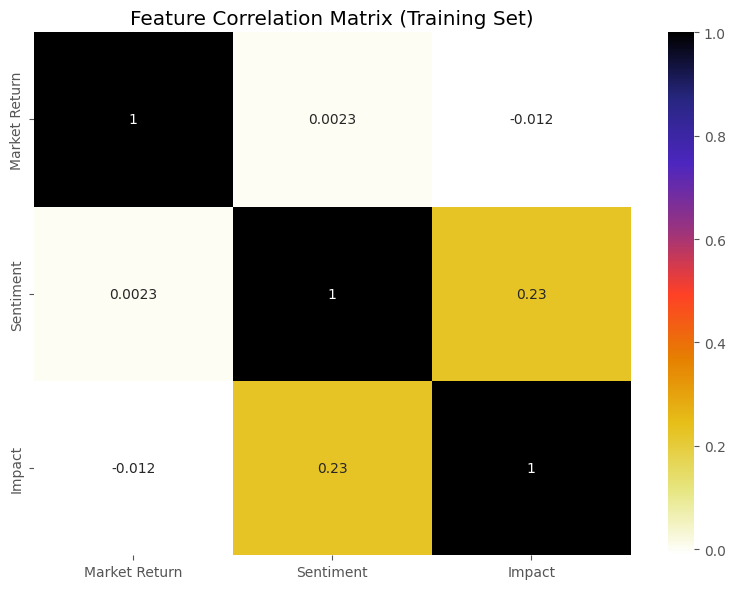


Accuracy Scores:
Logistic Regression: 0.6288
Random Forest: 0.6434
SVM: 0.6410
KNN: 0.6102
Decision Tree: 0.5916


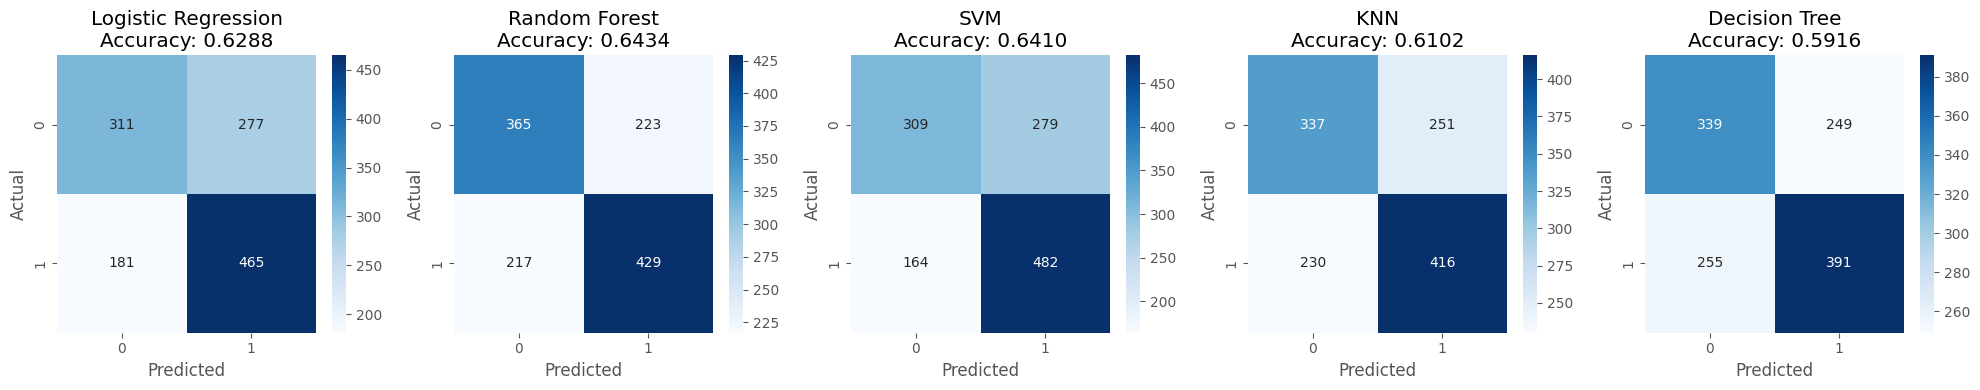

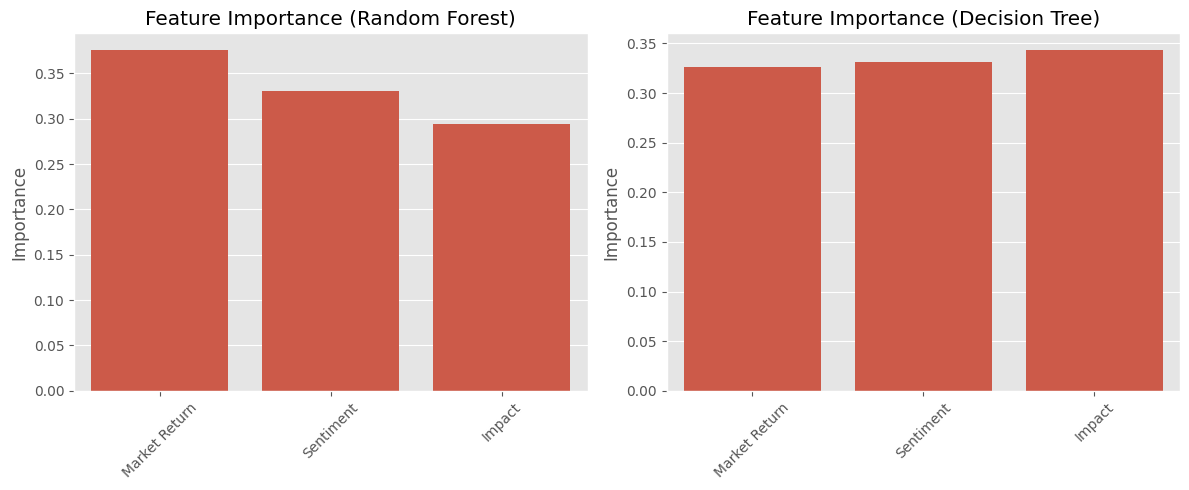


Class Distribution:
return_label
1    0.535755
0    0.464245
Name: proportion, dtype: float64


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sqlalchemy import func
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
plt.style.use('ggplot')

# Query to get stock prices for return calculation (including SPY)
stock_prices_query = (
    session.query(
        HistPrice1D.ticker,
        HistPrice1D.exch_time,
        HistPrice1D.close
    )
    .join(Securities, HistPrice1D.ticker == Securities.ticker)
    .filter(Securities.security_type == 'stk')
    .filter(HistPrice1D.exch_time >= '2023-11-01')
    .filter(HistPrice1D.exch_time <= '2024-09-30')
)

stock_prices_df = pd.read_sql(stock_prices_query.statement, session.bind)

# Convert exch_time to datetime and calculate weekly returns
stock_prices_df['exch_time'] = pd.to_datetime(stock_prices_df['exch_time'])
stock_prices_df['week'] = stock_prices_df['exch_time'].dt.to_period('W')
weekly_returns = stock_prices_df.groupby(['ticker', 'week'])['close'].agg(['first', 'last'])
weekly_returns['return'] = (weekly_returns['last'] - weekly_returns['first']) / weekly_returns['first']
weekly_returns = weekly_returns.reset_index()

# Separate SPY returns
spy_returns = weekly_returns[weekly_returns['ticker'] == 'SPY'][['week', 'return']]
spy_returns = spy_returns.rename(columns={'return': 'market_return'})

# Query to get sentiment and impact scores
sentiment_query = (
    session.query(
        NewsSecurities.ticker,
        News.published_utc,
        NewsSecurities.sentiment,
        NewsSecurities.impact
    )
    .join(News, NewsSecurities.news_id == News.id)
    .filter(News.published_utc >= '2023-11-01')
    .filter(News.published_utc <= '2024-09-30')
    .filter(News.content.isnot(None))
)

sentiment_df = pd.read_sql(sentiment_query.statement, session.bind)

# Process sentiment data
sentiment_df['published_utc'] = pd.to_datetime(sentiment_df['published_utc'])
sentiment_df['week'] = sentiment_df['published_utc'].dt.to_period('W')

# Calculate weekly average sentiment and impact scores
weekly_scores = sentiment_df.groupby(['ticker', 'week']).agg({
    'sentiment': 'mean',
    'impact': 'mean'
}).reset_index()

# Merge all data
merged_data = pd.merge(weekly_returns[weekly_returns['ticker'] != 'SPY'], 
                      spy_returns, on='week', how='inner')
merged_data = pd.merge(merged_data, weekly_scores, on=['ticker', 'week'], how='inner')

# Remove NaN values
merged_data = merged_data.dropna(subset=['market_return', 'sentiment', 'impact', 'return'])

# Print data info before proceeding
print("Dataset information after cleaning:")
print(f"Number of samples: {len(merged_data)}")
print("\nMissing values:")
print(merged_data[['market_return', 'sentiment', 'impact', 'return']].isnull().sum())

# Create binary classification labels (1 for positive return, 0 for negative)
merged_data['return_label'] = (merged_data['return'] > 0).astype(int)

# Prepare features and target
X = merged_data[['market_return', 'sentiment', 'impact']]
y = merged_data['return_label']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Move correlation analysis to after train/test split but before model training
print("\nCorrelation Analysis on Training Set:")
# Convert scaled training data back to dataframe with feature names
feature_names = ['Market Return', 'Sentiment', 'Impact']
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)

# Calculate correlation matrix
correlation_matrix = X_train_df.corr()

# Create heatmap with specified style
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap=plt.cm.CMRmap_r)
plt.title('Feature Correlation Matrix (Training Set)')
plt.tight_layout()
plt.show()

# Initialize classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

# Train and evaluate each classifier
results = {}
for name, clf in classifiers.items():
    # Train the model
    clf.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = clf.predict(X_test_scaled)
    
    # Store results
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'model': clf  # Store the trained model
    }

# Print accuracy scores
print("\nAccuracy Scores:")
for name, result in results.items():
    print(f"{name}: {result['accuracy']:.4f}")

# Plot confusion matrices
plt.figure(figsize=(20, 4))
for i, (name, result) in enumerate(results.items(), 1):
    plt.subplot(1, 5, i)
    sns.heatmap(result['confusion_matrix'], annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name}\nAccuracy: {result["accuracy"]:.4f}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# Feature importance for tree-based models
importance_data = []

# Get feature importance from Random Forest
rf_importance = results['Random Forest']['model'].feature_importances_
importance_data.append(('Random Forest', rf_importance))

# Get feature importance from Decision Tree
dt_importance = results['Decision Tree']['model'].feature_importances_
importance_data.append(('Decision Tree', dt_importance))

# Plot feature importance for both models
plt.figure(figsize=(12, 5))
for i, (name, importance) in enumerate(importance_data):
    plt.subplot(1, 2, i+1)
    sns.barplot(x=feature_names, y=importance)
    plt.title(f'Feature Importance ({name})')
    plt.xticks(rotation=45)
    plt.ylabel('Importance')

plt.tight_layout()
plt.show()

# Print class distribution
print("\nClass Distribution:")
print(y.value_counts(normalize=True))


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sqlalchemy import func
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
plt.style.use('ggplot')

# Query to get stock prices for return calculation (including SPY)
stock_prices_query = (
    session.query(
        HistPrice1D.ticker,
        HistPrice1D.exch_time,
        HistPrice1D.close,
        HistPrice1D.volume
    )
    .join(Securities, HistPrice1D.ticker == Securities.ticker)
    .filter(Securities.security_type == 'stk')
    .filter(HistPrice1D.exch_time >= '2023-11-01')
    .filter(HistPrice1D.exch_time <= '2024-09-30')
)

stock_prices_df = pd.read_sql(stock_prices_query.statement, session.bind)

# Convert exch_time to datetime and calculate weekly returns
stock_prices_df['exch_time'] = pd.to_datetime(stock_prices_df['exch_time'])
stock_prices_df['week'] = stock_prices_df['exch_time'].dt.to_period('W')
weekly_returns = stock_prices_df.groupby(['ticker', 'week'])['close'].agg(['first', 'last'])
weekly_returns['return'] = (weekly_returns['last'] - weekly_returns['first']) / weekly_returns['first']
weekly_returns = weekly_returns.reset_index()

# Calculate weekly turnover
stock_prices_df['turnover'] = stock_prices_df['close'] * stock_prices_df['volume']
weekly_turnover = stock_prices_df.groupby(['ticker', 'week'])['turnover'].sum().reset_index()

# Separate SPY returns
spy_returns = weekly_returns[weekly_returns['ticker'] == 'SPY'][['week', 'return']]
spy_returns = spy_returns.rename(columns={'return': 'market_return'})

# Query to get sentiment and impact scores
sentiment_query = (
    session.query(
        NewsSecurities.ticker,
        News.published_utc,
        NewsSecurities.sentiment,
        NewsSecurities.impact,
        func.length(News.content).label('content_length')
    )
    .join(News, NewsSecurities.news_id == News.id)
    .filter(News.published_utc >= '2023-11-01')
    .filter(News.published_utc <= '2024-09-30')
    .filter(News.content.isnot(None))
)

sentiment_df = pd.read_sql(sentiment_query.statement, session.bind)

# Process sentiment data
sentiment_df['published_utc'] = pd.to_datetime(sentiment_df['published_utc'])
sentiment_df['week'] = sentiment_df['published_utc'].dt.to_period('W')

# Calculate weekly average sentiment, impact scores and news length
weekly_scores = sentiment_df.groupby(['ticker', 'week']).agg({
    'sentiment': 'mean',
    'impact': 'mean',
    'content_length': 'mean'
}).reset_index()

# Merge all data
merged_data = pd.merge(weekly_returns[weekly_returns['ticker'] != 'SPY'], 
                      spy_returns, on='week', how='inner')
merged_data = pd.merge(merged_data, weekly_scores, on=['ticker', 'week'], how='inner')
merged_data = pd.merge(merged_data, weekly_turnover, on=['ticker', 'week'], how='inner')

# Remove NaN values
merged_data = merged_data.dropna(subset=['market_return', 'sentiment', 'impact', 'return', 
                                       'turnover', 'content_length'])

# Print data info
print("\nDataset information after cleaning:")
print(f"Number of samples: {len(merged_data)}")
print("\nMissing values:")
print(merged_data[['market_return', 'sentiment', 'impact', 'return', 
                  'turnover', 'content_length']].isnull().sum())

# Create binary classification labels
merged_data['return_label'] = (merged_data['return'] > 0).astype(int)



Dataset information after cleaning:
Number of samples: 6167

Missing values:
market_return     0
sentiment         0
impact            0
return            0
turnover          0
content_length    0
dtype: int64


In [3]:
merged_data.head()


,ticker,week,first,last,return,market_return,sentiment,impact,content_length,turnover,return_label
0,AA,2023-11-06/2023-11-12,25.97,24.64,-0.051213,0.011292,75.0,25.0,8589.0,4.933242e+08,0
1,AA,2023-11-13/2023-11-19,24.60,26.22,0.065854,0.024081,35.0,45.0,1472.0,6.078060e+08,1
2,AA,2023-11-20/2023-11-26,26.47,26.24,-0.008689,0.002289,50.0,55.0,5145.0,2.988984e+08,0
3,AA,2023-11-27/2023-12-03,26.30,27.74,0.054753,0.010165,55.0,45.0,6043.0,6.469608e+08,1
4,AA,2023-12-04/2023-12-10,26.81,25.02,-0.066766,0.007686,25.0,45.0,2827.0,7.260514e+08,0


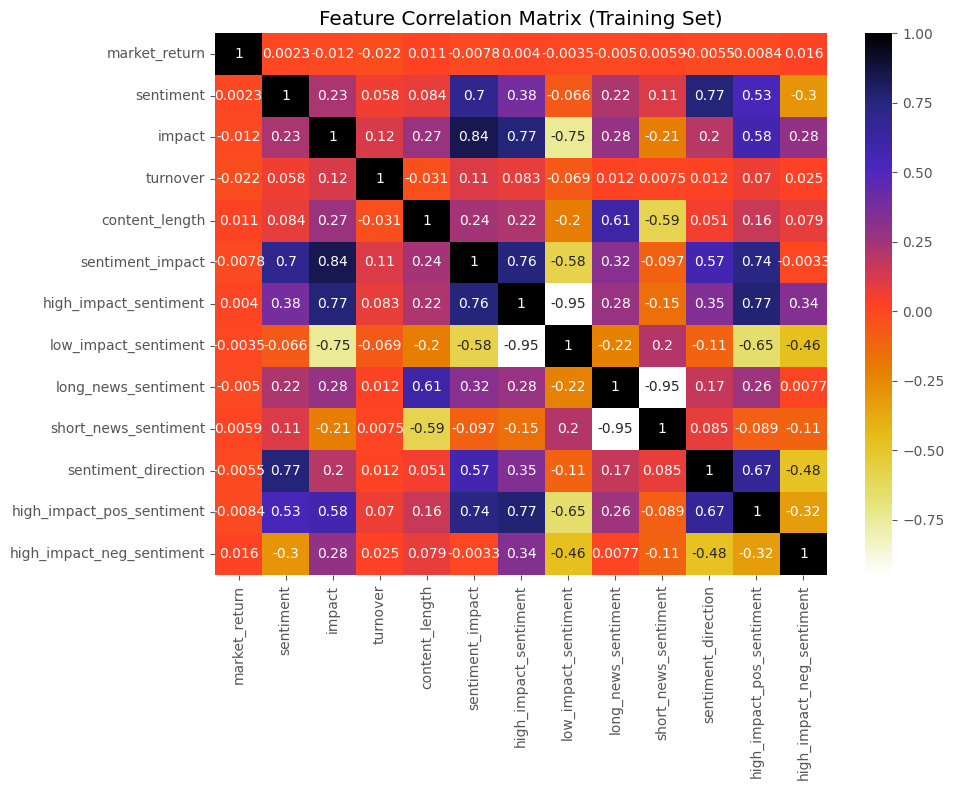


Highly Correlated Feature Pairs (|correlation| > 0.5):
sentiment_impact -- sentiment: 0.703
sentiment_impact -- impact: 0.844
high_impact_sentiment -- impact: 0.768
high_impact_sentiment -- sentiment_impact: 0.764
low_impact_sentiment -- impact: -0.749
low_impact_sentiment -- sentiment_impact: -0.583
low_impact_sentiment -- high_impact_sentiment: -0.949
long_news_sentiment -- content_length: 0.607
short_news_sentiment -- content_length: -0.590
short_news_sentiment -- long_news_sentiment: -0.946
sentiment_direction -- sentiment: 0.770
sentiment_direction -- sentiment_impact: 0.567
high_impact_pos_sentiment -- sentiment: 0.535
high_impact_pos_sentiment -- impact: 0.581
high_impact_pos_sentiment -- sentiment_impact: 0.740
high_impact_pos_sentiment -- high_impact_sentiment: 0.775
high_impact_pos_sentiment -- low_impact_sentiment: -0.652
high_impact_pos_sentiment -- sentiment_direction: 0.671


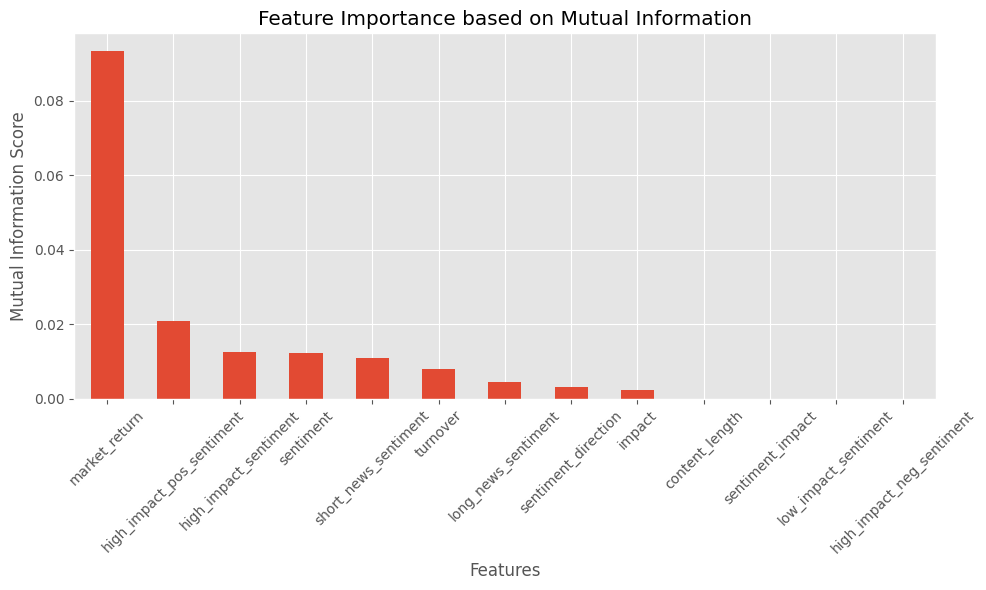


Mutual Information Scores:
market_return                0.093435
high_impact_pos_sentiment    0.020964
high_impact_sentiment        0.012628
sentiment                    0.012189
short_news_sentiment         0.010775
turnover                     0.007990
long_news_sentiment          0.004395
sentiment_direction          0.003226
impact                       0.002419
content_length               0.000000
sentiment_impact             0.000000
low_impact_sentiment         0.000000
high_impact_neg_sentiment    0.000000
dtype: float64

Top 5 Selected Features:
Index(['market_return', 'sentiment', 'high_impact_sentiment',
       'short_news_sentiment', 'high_impact_pos_sentiment'],
      dtype='object')


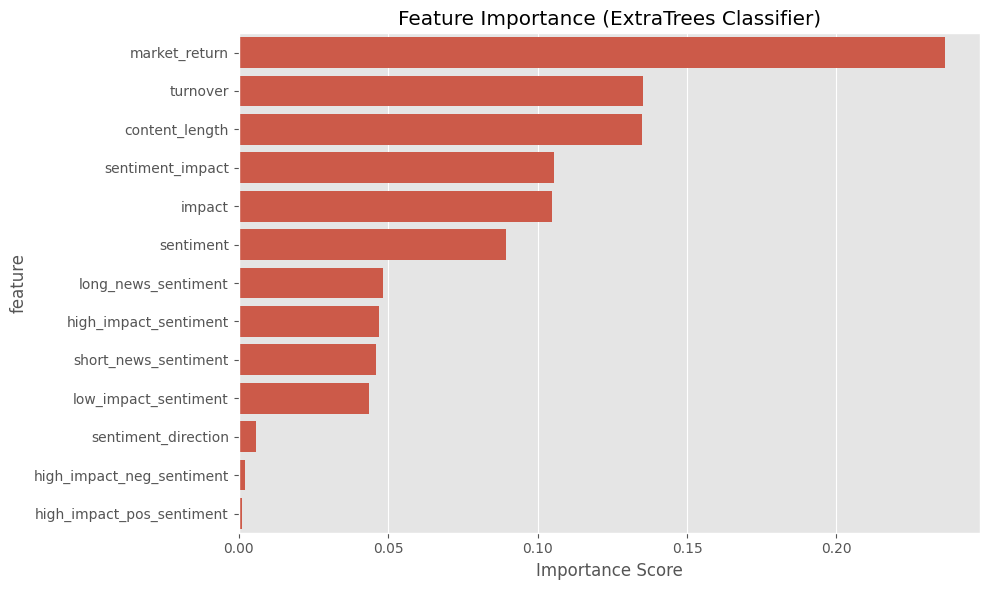


ExtraTrees Feature Importance:
                      feature  importance
0               market_return    0.236202
3                    turnover    0.135208
4              content_length    0.134831
5            sentiment_impact    0.105507
2                      impact    0.104851
1                   sentiment    0.089463
8         long_news_sentiment    0.048212
6       high_impact_sentiment    0.047055
9        short_news_sentiment    0.046052
7        low_impact_sentiment    0.043591
10        sentiment_direction    0.005688
12  high_impact_neg_sentiment    0.002147
11  high_impact_pos_sentiment    0.001193

Performing GridSearchCV for logistic_regression...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Performing GridSearchCV for random_forest...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Performing GridSearchCV for svm...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Performing GridSearchCV for knn...
Fitting 5 folds for each

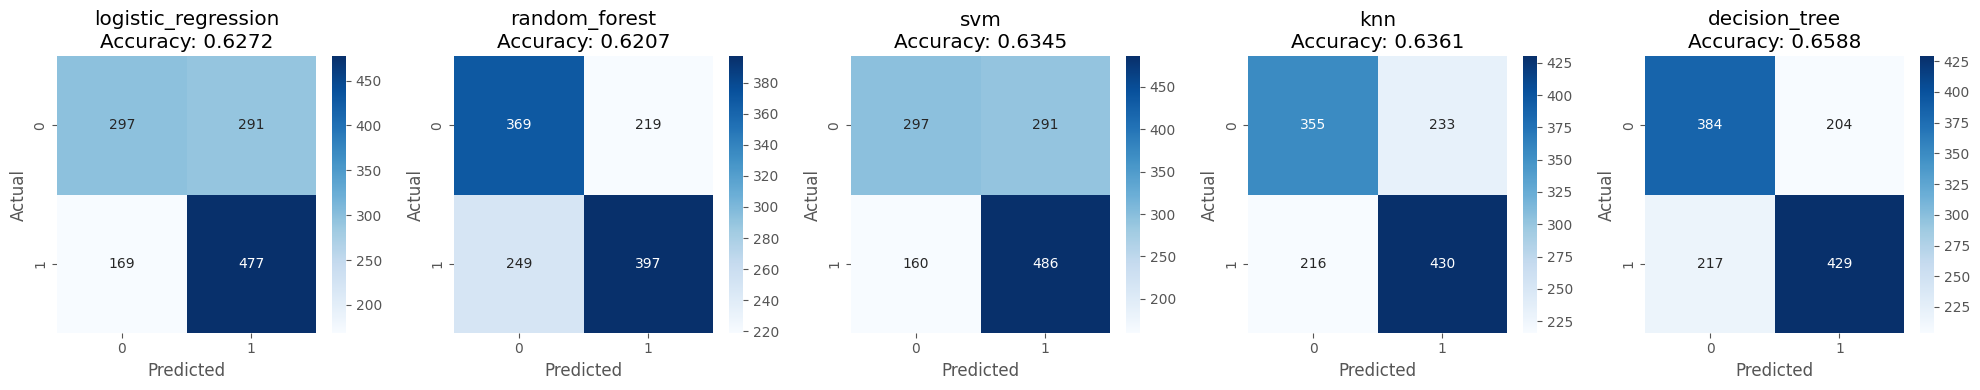


Descriptive statistics after aggregation:
           return  market_return   sentiment      impact
count  342.000000     342.000000  342.000000  342.000000
mean     0.006331       0.005637   67.216406   49.973893
std      0.016516       0.005328    6.685103    5.064550
min     -0.096491      -0.013577   44.103652   17.500000
25%     -0.001597       0.003652   62.893378   47.375953
50%      0.006217       0.005800   68.268612   50.270319
75%      0.015397       0.007894   71.876275   53.227698
max      0.073935       0.034813   80.039683   68.333333

Clustering Data Statistics:
           return  market_return   sentiment      impact
count  342.000000     342.000000  342.000000  342.000000
mean     0.603326       0.397066    0.643164    0.638831
std      0.096907       0.110105    0.186028    0.099630
min      0.000000       0.000000    0.000000    0.000000
25%      0.556808       0.356044    0.522866    0.587724
50%      0.602658       0.400442    0.672444    0.644662
75%      0.65652

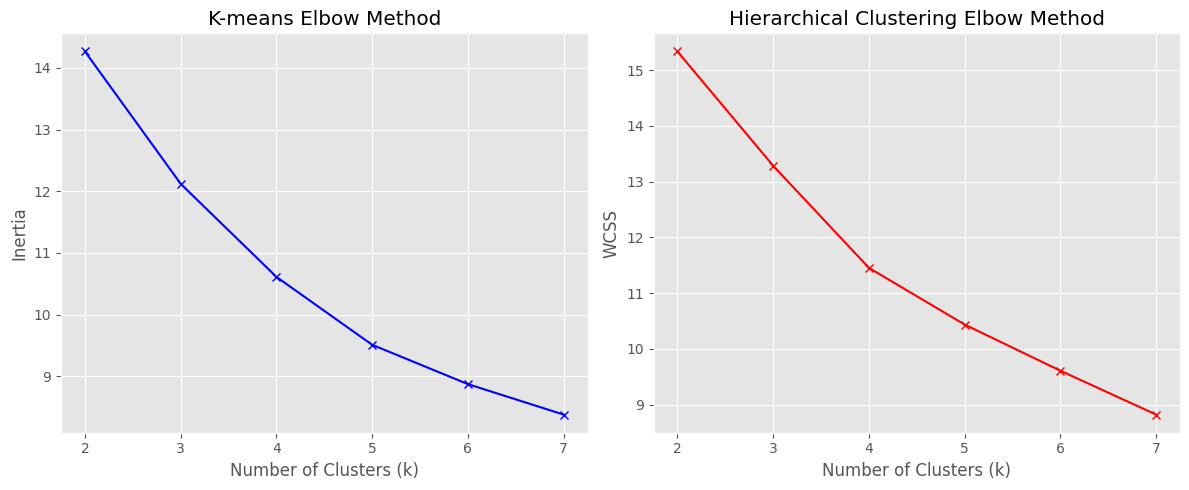

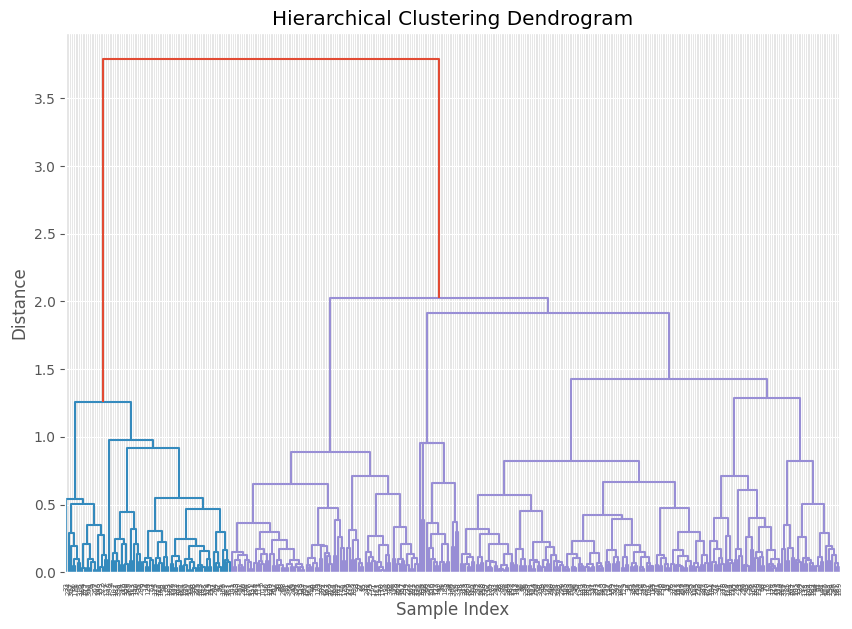


K-means Cluster Characteristics:
                   return  market_return  sentiment     impact
K-means_Cluster                                               
0                0.027682       0.013233  67.322117  48.063367
1                0.002067       0.003620  66.449273  48.847250
2                0.007359       0.004959  73.353753  52.661639
3               -0.001465       0.005830  56.469750  47.953328

K-means Top 5 stocks in each cluster:

Cluster 0 (40 stocks):
['MLCO', 'WSM', 'ASO', 'BURL', 'FIVE']

Cluster 1 (115 stocks):
['MMM', 'RKT', 'TAL', 'CPNG', 'GNRC']

Cluster 2 (124 stocks):
['DHI', 'LNG', 'SPOT', 'GILD', 'KKR']

Cluster 3 (63 stocks):
['PAA', 'UAL', 'BABA', 'ADI', 'BUD']

Hierarchical Cluster Characteristics:
                        return  market_return  sentiment     impact
Hierarchical_Cluster                                               
0                     0.004296       0.004576  68.361902  49.754344
1                    -0.004062       0.004685  57.657210

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, make_scorer, silhouette_score
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage


def prepare_data(merged_data):
    """
    Data preparation including feature engineering, normalization, and scaling
    """
    # Initial feature selection
    feature_columns = ['market_return', 'sentiment', 'impact', 'turnover', 'content_length']
    X = merged_data[feature_columns].copy()
    y = merged_data['return_label']

    # Log transform turnover
    X['turnover'] = np.log1p(X['turnover'])

    # Create interaction terms
    X['sentiment_impact'] = X['sentiment'] * X['impact']
    X['high_impact_sentiment'] = X['sentiment'] * (X['impact'] > X['impact'].median())
    X['low_impact_sentiment'] = X['sentiment'] * (X['impact'] <= X['impact'].median())
    X['long_news_sentiment'] = X['sentiment'] * (X['content_length'] > X['content_length'].median())
    X['short_news_sentiment'] = X['sentiment'] * (X['content_length'] <= X['content_length'].median())
    X['sentiment_direction'] = (X['sentiment'] > X['sentiment'].median()).astype(int)
    X['high_impact_pos_sentiment'] = ((X['sentiment'] > X['sentiment'].median()) & (X['impact'] > X['impact'].median())).astype(int)
    X['high_impact_neg_sentiment'] = ((X['sentiment'] <= X['sentiment'].median()) & (X['impact'] > X['impact'].median())).astype(int)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Scale features
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, scaler, X, y

def prepare_clustering_data(merged_data, X, y):
    """
    Prepares and scales data for clustering by aggregating features by ticker
    """
    # Get the features we want for clustering
    clustering_features = ['market_return', 'sentiment', 'impact']
    
    # Create DataFrame with all needed features
    cluster_df = pd.DataFrame({
        'ticker': merged_data['ticker'],
        'return': merged_data['return'],  # Using actual returns instead of binary labels
    })
    
    # Add selected X features
    for feature in clustering_features:
        cluster_df[feature] = X[feature]
    
    # Aggregate by ticker
    agg_dict = {
        'return': 'mean',  # This will now calculate mean of actual returns
        'market_return': 'mean',
        'sentiment': 'mean',
        'impact': 'mean'
    }
    
    ticker_data = cluster_df.groupby('ticker').agg(agg_dict).reset_index()
    
    # Print statistics to verify the data
    print("\nDescriptive statistics after aggregation:")
    print(ticker_data.describe())
    
    # Prepare data for clustering
    features_for_clustering = ['return', 'market_return', 'sentiment', 'impact']
    X_cluster = ticker_data[features_for_clustering]
    
    # Scale the data
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(X_cluster)
    
    return ticker_data, scaled_data, features_for_clustering

def analyze_feature_importance(X_train, X_train_scaled, y_train):
    """
    Feature selection and importance analysis including correlation analysis
    """
    # Create DataFrame with scaled features for correlation analysis
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    
    # Calculate and plot correlation matrix
    correlation_matrix = X_train_scaled_df.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap=plt.cm.CMRmap_r)
    plt.title('Feature Correlation Matrix (Training Set)')
    plt.tight_layout()
    plt.show()

    # Print highly correlated feature pairs
    print("\nHighly Correlated Feature Pairs (|correlation| > 0.5):")
    high_corr_features = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i):
            if abs(correlation_matrix.iloc[i, j]) > 0.5:
                print(f"{correlation_matrix.columns[i]} -- {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.3f}")
                high_corr_features.append((correlation_matrix.columns[i], correlation_matrix.columns[j]))

    # Calculate mutual information
    mutual_info = mutual_info_classif(X_train_scaled, y_train, random_state=15)
    mutual_info_series = pd.Series(mutual_info, index=X_train.columns)

    # Plot mutual information scores
    plt.figure(figsize=(10, 6))
    mutual_info_series.sort_values(ascending=False).plot.bar()
    plt.title('Feature Importance based on Mutual Information')
    plt.xlabel('Features')
    plt.ylabel('Mutual Information Score')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Select top features
    selector = SelectKBest(score_func=lambda X, y: mutual_info_classif(X, y, random_state=15), k=5)  # <- CHANGE HERE

    selector.fit(X_train_scaled, y_train)
    selected_features = X_train.columns[selector.get_support()]

    print("\nMutual Information Scores:")
    print(mutual_info_series.sort_values(ascending=False))
    print("\nTop 5 Selected Features:")
    print(selected_features)

    # Add ExtraTrees feature importance
    extra_trees = ExtraTreesClassifier(random_state=15)
    extra_trees.fit(X_train_scaled, y_train)
    
    # Create feature importance DataFrame
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': extra_trees.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Plot ExtraTrees feature importance
    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='feature', data=feature_importance)
    plt.title('Feature Importance (ExtraTrees Classifier)')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
    
    print("\nExtraTrees Feature Importance:")
    print(feature_importance)

    return selector

def perform_classification_analysis(X_train_scaled, X_test_scaled, y_train, y_test, selected_columns, feature_names):
    """
    Classification analysis with multiple models using GridSearchCV for parameter optimization
    """
    # Get indices of selected columns
    selected_indices = [feature_names.index(col) for col in selected_columns]
    
    # Select specified columns
    X_train_selected = X_train_scaled[:, selected_indices]
    X_test_selected = X_test_scaled[:, selected_indices]

    # Define model parameters for grid search
    model_params = {
        'logistic_regression': {
            'model': LogisticRegression(random_state=42),
            'params': {
                'C': [0.001, 0.01, 0.1, 1, 10, 100],
                'penalty': ['l1', 'l2'],
                'solver': ['liblinear'],
                'class_weight': [None, 'balanced']
            }
        },
        'random_forest': {
            'model': RandomForestClassifier(random_state=42),
            'params': {
                'n_estimators': [100, 200, 300],
                'max_depth': [None, 10, 20, 30],
                'min_samples_split': [2, 5, 10],
                'class_weight': [None, 'balanced']
            }
        },
        'svm': {
            'model': SVC(random_state=42),
            'params': {
                'C': [0.1, 1, 10],
                'kernel': ['rbf', 'linear'],
                'gamma': ['scale', 'auto'],
                'class_weight': [None, 'balanced']
            }
        },
        'knn': {
            'model': KNeighborsClassifier(),
            'params': {
                'n_neighbors': [3, 5, 7, 9],
                'weights': ['uniform', 'distance'],
                'metric': ['euclidean', 'manhattan']
            }
        },
        'decision_tree': {
            'model': DecisionTreeClassifier(random_state=42),
            'params': {
                'max_depth': [None, 10, 20, 30],
                'min_samples_split': [2, 5, 10],
                'criterion': ['gini', 'entropy'],
                'class_weight': [None, 'balanced']
            }
        }
    }

    # Define scoring metrics
    scoring = {
        'accuracy': make_scorer(accuracy_score),
        'precision': make_scorer(precision_score),
        'recall': make_scorer(recall_score),
        'f1': make_scorer(f1_score)
    }

    # Perform grid search for each model
    results = []
    for model_name, mp in model_params.items():
        print(f"\nPerforming GridSearchCV for {model_name}...")
        
        clf = GridSearchCV(
            mp['model'], 
            mp['params'], 
            cv=5, 
            scoring=scoring,
            refit='accuracy',  # Use accuracy for selecting best model
            n_jobs=-1,  # Use all available cores
            verbose=1
        )
        
        clf.fit(X_train_selected, y_train)
        
        # Make predictions with best model
        y_pred = clf.predict(X_test_selected)
        
        # Store results
        results.append({
            'model': model_name,
            'best_params': clf.best_params_,
            'best_train_score': clf.best_score_,
            'test_accuracy': accuracy_score(y_test, y_pred),
            'test_precision': precision_score(y_test, y_pred),
            'test_recall': recall_score(y_test, y_pred),
            'test_f1': f1_score(y_test, y_pred),
            'confusion_matrix': confusion_matrix(y_test, y_pred),
            'best_estimator': clf.best_estimator_
        })

    # Convert results to DataFrame
    results_df = pd.DataFrame(results)
    
    # Print results
    print("\nModel Performance Summary:")
    print(results_df[['model', 'best_train_score', 'test_accuracy', 'test_precision', 'test_recall', 'test_f1']])
    
    print("\nBest Parameters for Each Model:")
    for result in results:
        print(f"\n{result['model']}:")
        print(result['best_params'])

    # Plot confusion matrices for all models
    plt.figure(figsize=(20, 4))
    for i, result in enumerate(results, 1):
        plt.subplot(1, 5, i)
        sns.heatmap(result['confusion_matrix'], annot=True, fmt='d', cmap='Blues')
        plt.title(f"{result['model']}\nAccuracy: {result['test_accuracy']:.4f}")
        plt.xlabel('Predicted')
        plt.ylabel('Actual')

    plt.tight_layout()
    plt.show()

    return results_df, results

def calculate_wcss(data, labels):
    """
    Calculate Within-Cluster Sum of Squares (WCSS)
    """
    n_clusters = len(np.unique(labels))
    wcss = 0
    for i in range(n_clusters):
        cluster_points = data[labels == i]
        cluster_center = np.mean(cluster_points, axis=0)
        wcss += np.sum((cluster_points - cluster_center) ** 2)
    return wcss

def perform_clustering_analysis(ticker_data, scaled_data, features_for_clustering, n_top_stocks=5):
    """
    Performs K-means and hierarchical clustering analysis on ticker-level data
    """
    # Print initial cluster data statistics
    print("\nClustering Data Statistics:")
    print(pd.DataFrame(scaled_data, columns=features_for_clustering).describe())

    # Find optimal K for both methods
    K = range(2, 8)
    
    # K-means elbow curve
    kmeans_inertias = []
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(scaled_data)
        kmeans_inertias.append(kmeans.inertia_)
    
    # Hierarchical clustering elbow curve
    hc_distortions = []
    for k in K:
        hc = AgglomerativeClustering(n_clusters=k)
        labels = hc.fit_predict(scaled_data)
        wcss = calculate_wcss(scaled_data, labels)
        hc_distortions.append(wcss)
    
    # Plot elbow curves
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(K, kmeans_inertias, 'bx-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.title('K-means Elbow Method')
    
    plt.subplot(1, 2, 2)
    plt.plot(K, hc_distortions, 'rx-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('WCSS')
    plt.title('Hierarchical Clustering Elbow Method')
    plt.tight_layout()
    plt.show()
    
    # Perform both clustering methods with optimal K (using k=4 for this example)
    # K-means clustering
    kmeans = KMeans(n_clusters=4, random_state=42)
    kmeans_labels = kmeans.fit_predict(scaled_data)
    
    # Hierarchical clustering
    hc = AgglomerativeClustering(n_clusters=4)
    hc_labels = hc.fit_predict(scaled_data)
    
    # Plot dendrogram for hierarchical clustering
    linkage_matrix = linkage(scaled_data, method='ward')
    plt.figure(figsize=(10, 7))
    dendrogram(linkage_matrix)
    plt.title('Hierarchical Clustering Dendrogram')
    plt.xlabel('Sample Index')
    plt.ylabel('Distance')
    plt.show()
    
    # Analyze clusters for both methods
    results = {}
    for method, labels in [('K-means', kmeans_labels), ('Hierarchical', hc_labels)]:
        ticker_data[f'{method}_Cluster'] = labels
        
        # Calculate cluster characteristics
        cluster_stats = ticker_data.groupby(f'{method}_Cluster')[features_for_clustering].mean()
        print(f"\n{method} Cluster Characteristics:")
        print(cluster_stats)
        
        # Get top stocks for each cluster
        print(f"\n{method} Top {n_top_stocks} stocks in each cluster:")
        for cluster in range(4):
            cluster_stocks = ticker_data[ticker_data[f'{method}_Cluster'] == cluster]
            top_stocks = cluster_stocks.nlargest(n_top_stocks, 'return')
            print(f"\nCluster {cluster} ({len(cluster_stocks)} stocks):")
            print(top_stocks['ticker'].tolist())
        
        results[method] = {
            'labels': labels,
            'cluster_stats': cluster_stats
        }
    
    return results

# Update the main function to use the new classification analysis
def main(merged_data):
    # 1. Data Preparation
    X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, scaler, X, y = prepare_data(merged_data)
    
    # 2. Feature Selection and Analysis
    selector = analyze_feature_importance(X_train, X_train_scaled, y_train)
    
    # 3. Classification Analysis
    selected_columns = ['market_return', 'high_impact_sentiment', 'short_news_sentiment']
    results_df, results = perform_classification_analysis(
        X_train_scaled, 
        X_test_scaled, 
        y_train, 
        y_test, 
        selected_columns, 
        list(X_train.columns)
    )
    
    # 4. Clustering Analysis
    ticker_data, scaled_data, features_for_clustering = prepare_clustering_data(merged_data, X, y)
    clustering_results = perform_clustering_analysis(
        ticker_data,
        scaled_data,
        features_for_clustering,
        n_top_stocks=5
    )
    
    return results_df, results, selector, scaler, cluster_labels, cluster_stats

# Run the analysis
results_df, results, selector, scaler, cluster_labels, cluster_stats = main(merged_data)